# Part C
## Conditional Latent Diffusion Models (With Drift Analysis and Adaptive Trajectory Correction)



## What You Will Build

| Task | Topic |
|------|-------|
| **C.1** | Train a Convolutional VAE on MNIST |
| **C.2** | Latent Space Analysis & Normalization |
| **C.3** | Class-Conditional Latent Diffusion (CFG) |
| **C.4** | Latent Drift: Understanding & Measuring It |
| **C.5** | Mitigating Drift: Adaptive Trajectory Correction |
| **C.6** | Evaluation: Does Correction Actually Help? |
| **C.7** | Analytical Questions |

---

## Background

### Why Latent Space?
Latent Diffusion Models (Rombach et al., 2022) run the diffusion process in the compressed latent space of a pretrained VAE. This reduces the spatial resolution from $28 \times 28$ to $7 \times 7$ (4× downsampling), making diffusion significantly cheaper while preserving perceptual quality.

### What is Latent Drift?
During the reverse diffusion process, the model iteratively predicts and removes noise. However, each denoising step introduces small prediction errors. These errors **accumulate** across the $T$ steps — the predicted $x_{t-1}$ drifts away from the true posterior trajectory. This is especially pronounced in:
- Long reverse chains ($T = 1000$)
- Conditional models where the conditioning signal is weak
- The early reverse steps (high $t$) where the model has the least signal

### Adaptive Correction
Drawing inspiration from ADA (Adaptive Data Augmentation, Karras et al., 2020) and Langevin dynamics, we can insert **correction steps** during sampling that push $x_t$ back toward a well-behaved region — either toward the data manifold, toward the correct class, or toward a lower-energy state under the learned score. The key design question is: *how often, and how strongly, should we correct?*

---
## Setup

In [1]:
!pip install torch torchvision matplotlib tqdm einops scikit-learn --quiet

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
import numpy as np
from tqdm.notebook import tqdm
import math
from einops import rearrange
from torch.optim import Adam
from torch.utils.data import DataLoader
from sklearn.manifold import TSNE
import time
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

torch.manual_seed(42)
np.random.seed(42)

Device: cuda


---
# C.1 — Convolutional VAE

Your VAE maps $28 \times 28$ MNIST images to a latent of shape $(C_z, 7, 7)$ via 2× spatial downsampling at each of two encoder stages.

**Architecture requirements:**
- **Encoder:** 3 Conv layers (strides 1, 2, 2) to reach $7 \times 7$. Output separate $\mu$ and $\log \sigma^2$ heads.
- **Reparameterization:** $z = \mu + \sigma \odot \epsilon$, $\epsilon \sim \mathcal{N}(0,I)$
- **Decoder:** Transpose convolutions (or upsample + conv) from $7 \times 7$ back to $28 \times 28$. Tanh output (images in $[-1,1]$).
- **Loss:** $\mathcal{L} = \mathcal{L}_{\text{recon}} + \lambda_{\text{KL}} \cdot D_{\text{KL}}$
  - $\mathcal{L}_{\text{recon}} = \text{MSE}(x, \hat{x})$
  - $D_{\text{KL}} = -\frac{1}{2}\sum_j(1 + \log\sigma_j^2 - \mu_j^2 - \sigma_j^2)$

**Deliverables after training:**
1. Training loss curve (total, recon, KL on separate axes).
2. 8 original/reconstruction side-by-side pairs.
3. t-SNE of $\mu$ vectors from 1000 test images, colored by digit class.

In [3]:
# Data — normalize to [-1, 1]
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x * 2 - 1)
])

train_dataset = datasets.MNIST('./data', train=True,  download=True, transform=transform)
test_dataset  = datasets.MNIST('./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=256, shuffle=False, num_workers=2, pin_memory=True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 58.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.64MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 13.0MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 4.88MB/s]


In [4]:
LATENT_CH = 4  # C_z — you may change this; document your choice

class Encoder(nn.Module):
    """
    TODO: Convolutional encoder.
    Input:  (B, 1, 28, 28)
    Output: mu (B, LATENT_CH, 7, 7), log_var (B, LATENT_CH, 7, 7)

    Suggested channel progression: 1 -> 32 -> 64 -> LATENT_CH*2
    Use strides [1, 2, 2] to go 28 -> 28 -> 14 -> 7.
    Split the final output into mu and log_var along the channel dim.
    """
    def __init__(self, latent_ch=LATENT_CH):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1,  32, 3, stride=1, padding=1),
            nn.SiLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1),
            nn.SiLU(),
            nn.Conv2d(64, latent_ch * 2, 3, stride=2, padding=1),
        )
        # YOUR CODE HERE


    def forward(self, x):
        # YOUR CODE HERE
        h = self.net(x)
        mu, log_var = h.chunk(2, dim=1)
        return mu, log_var


class Decoder(nn.Module):
    """
    TODO: Convolutional decoder.
    Input:  (B, LATENT_CH, 7, 7)
    Output: (B, 1, 28, 28)  — use Tanh for [-1,1] range

    Mirror the encoder: upsample 7 -> 14 -> 28.
    You may use ConvTranspose2d or nn.Upsample + Conv2d.
    """
    def __init__(self, latent_ch=LATENT_CH):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(latent_ch, 64, 4, stride=2, padding=1),
            nn.SiLU(),
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1),
            nn.SiLU(),
            nn.Conv2d(32, 1, 3, stride=1, padding=1),
            nn.Tanh(),
        )
        # YOUR CODE HERE

    def forward(self, z):
        # YOUR CODE HERE
        return self.net(z)


class VAE(nn.Module):
    def __init__(self, latent_ch=LATENT_CH):
        super().__init__()
        self.encoder = Encoder(latent_ch)
        self.decoder = Decoder(latent_ch)

    def reparameterize(self, mu, log_var):
        """
        TODO: Implement the reparameterization trick.
        During inference you may want to just return mu (no noise).
        """
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return mu + std * eps

    def encode(self, x):
        """Return the deterministic latent mu (used during LDM training)."""
        mu, log_var = self.encoder(x)
        return mu

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, log_var = self.encoder(x)
        z = self.reparameterize(mu, log_var)
        x_recon = self.decoder(z)
        return x_recon, mu, log_var


def vae_loss(x, x_recon, mu, log_var, kl_weight=1e-3):
    """
    TODO: Compute VAE loss = recon_loss + kl_weight * kl_loss.
    Return a dict: {'total': ..., 'recon': ..., 'kl': ...}
    """
    recon = F.mse_loss(x_recon, x, reduction='mean')
    kl    = -0.5 * torch.mean(1 + log_var - mu.pow(2) - log_var.exp())
    total = recon + kl_weight * kl
    return {'total': total, 'recon': recon, 'kl': kl}

In [5]:
# Sanity check before training
vae_test = VAE().to(device)
x_test = torch.randn(4, 1, 28, 28).to(device)
x_recon, mu, log_var = vae_test(x_test)
assert x_recon.shape == (4, 1, 28, 28), f"Decoder output shape wrong: {x_recon.shape}"
assert mu.shape == (4, LATENT_CH, 7, 7),  f"Latent shape wrong: {mu.shape}"
print("VAE shape check passed.")

VAE shape check passed.


In [6]:
# ── VAE Training ──────────────────────────────────────────────────────────────
"""
TODO: Train the VAE for at least 20 epochs.

Requirements:
  - Optimizer: Adam, lr=1e-3
  - Track total loss, recon loss, and KL loss per epoch
  - Save the best model (lowest total validation loss) as 'vae_best.pt'
"""

VAE_EPOCHS = 25
vae = VAE().to(device)
vae_optimizer = Adam(vae.parameters(), lr=1e-3)

# YOUR CODE HERE
best_vae_loss = float('inf')
train_losses = {'total': [], 'recon': [], 'kl': []}

print(f"Training VAE for {VAE_EPOCHS} epochs...")
for epoch in range(VAE_EPOCHS):
    vae.train()
    epoch_totals = {'total': 0.0, 'recon': 0.0, 'kl': 0.0}

    for x, _ in train_loader:
        x = x.to(device)
        x_recon, mu, log_var = vae(x)
        losses = vae_loss(x, x_recon, mu, log_var, kl_weight=1e-3)

        vae_optimizer.zero_grad()
        losses['total'].backward()
        vae_optimizer.step()

        for k in epoch_totals:
            epoch_totals[k] += losses[k].item()

    n = len(train_loader)
    for k in train_losses:
        train_losses[k].append(epoch_totals[k] / n)

    print(f"Epoch {epoch+1:3d}/{VAE_EPOCHS} | total={train_losses['total'][-1]:.4f} "
          f"recon={train_losses['recon'][-1]:.4f} kl={train_losses['kl'][-1]:.4f}")

    if train_losses['total'][-1] < best_vae_loss:
        best_vae_loss = train_losses['total'][-1]
        torch.save(vae.state_dict(), 'vae_best.pt')
        print(f"best vaesaved (loss={best_vae_loss:.4f})")

vae.load_state_dict(torch.load('vae_best.pt', map_location=device))
vae.eval()


Training VAE for 25 epochs...
Epoch   1/25 | total=0.1217 recon=0.1180 kl=3.7232
best vaesaved (loss=0.1217)
Epoch   2/25 | total=0.0145 recon=0.0121 kl=2.3709
best vaesaved (loss=0.0145)
Epoch   3/25 | total=0.0106 recon=0.0085 kl=2.0492
best vaesaved (loss=0.0106)
Epoch   4/25 | total=0.0093 recon=0.0073 kl=1.9431
best vaesaved (loss=0.0093)
Epoch   5/25 | total=0.0086 recon=0.0067 kl=1.8914
best vaesaved (loss=0.0086)
Epoch   6/25 | total=0.0081 recon=0.0063 kl=1.8654
best vaesaved (loss=0.0081)
Epoch   7/25 | total=0.0078 recon=0.0060 kl=1.8467
best vaesaved (loss=0.0078)
Epoch   8/25 | total=0.0076 recon=0.0057 kl=1.8299
best vaesaved (loss=0.0076)
Epoch   9/25 | total=0.0074 recon=0.0056 kl=1.8178
best vaesaved (loss=0.0074)
Epoch  10/25 | total=0.0072 recon=0.0054 kl=1.8056
best vaesaved (loss=0.0072)
Epoch  11/25 | total=0.0071 recon=0.0053 kl=1.7961
best vaesaved (loss=0.0071)
Epoch  12/25 | total=0.0069 recon=0.0052 kl=1.7767
best vaesaved (loss=0.0069)
Epoch  13/25 | total=0

VAE(
  (encoder): Encoder(
    (net): Sequential(
      (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): SiLU()
      (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (3): SiLU()
      (4): Conv2d(64, 8, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    )
  )
  (decoder): Decoder(
    (net): Sequential(
      (0): ConvTranspose2d(4, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (1): SiLU()
      (2): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (3): SiLU()
      (4): Conv2d(32, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (5): Tanh()
    )
  )
)

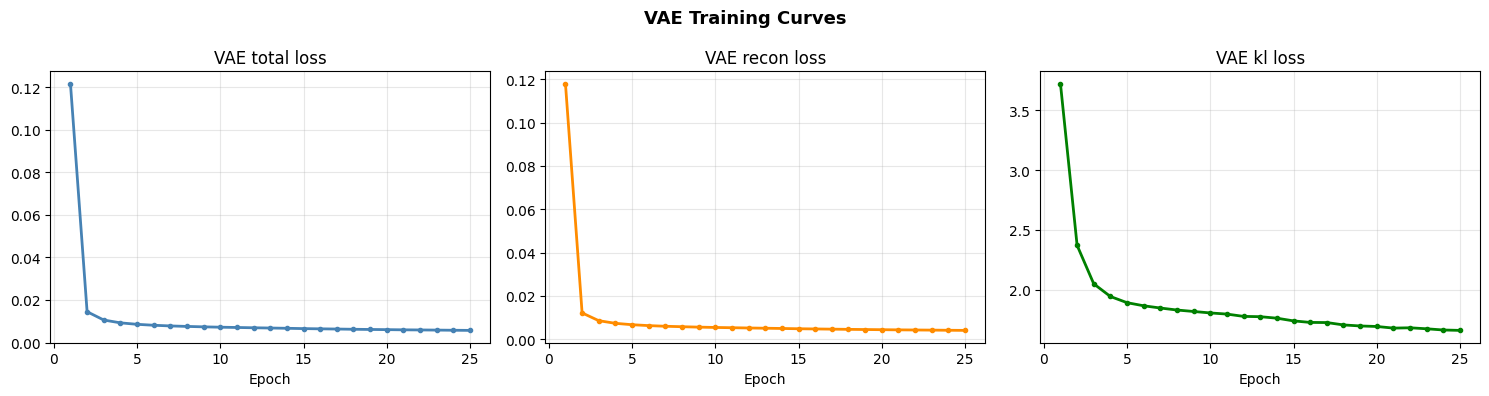

In [7]:
# ── Plot VAE training curves ───────────────────────────────────────────────────
"""
TODO: Plot total loss, recon loss, and KL loss on separate subplots.
"""
# YOUR CODE HERE
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
labels = ['total', 'recon', 'kl']
colors = ['steelblue', 'darkorange', 'green']
for ax, key, col in zip(axes, labels, colors):
    ax.plot(range(1, VAE_EPOCHS+1), train_losses[key], color=col, linewidth=2, marker='o', markersize=3)
    ax.set_title(f'VAE {key} loss')
    ax.set_xlabel('Epoch')
    ax.grid(True, alpha=0.3)
plt.suptitle('VAE Training Curves', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('vae_training_curves.png', dpi=100, bbox_inches='tight')
plt.show()

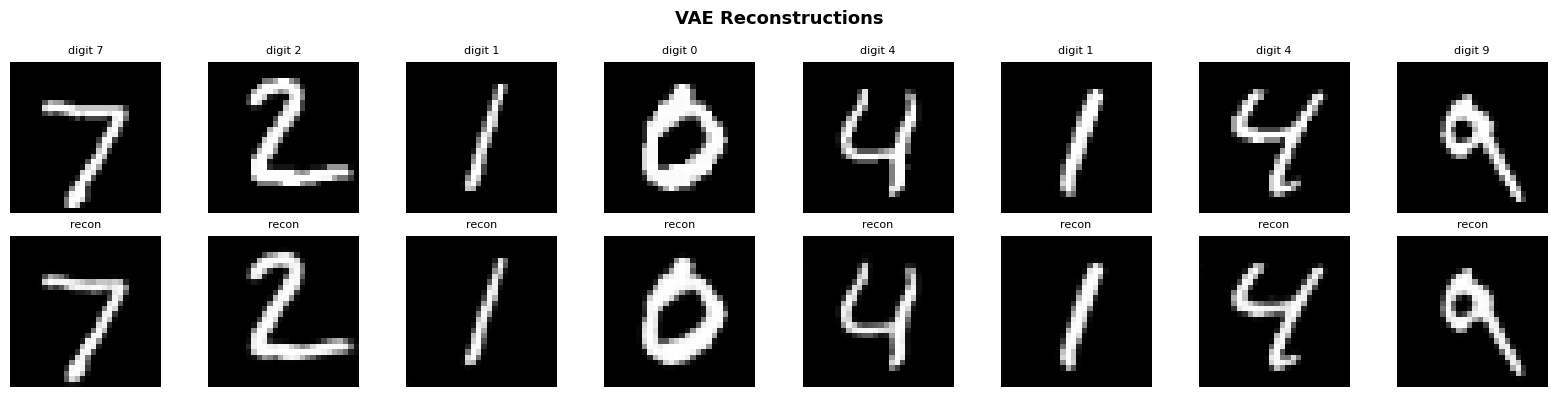

In [8]:
# ── Visualize reconstructions ─────────────────────────────────────────────────
"""
TODO: For 8 test images, show: [original | reconstruction] pairs side-by-side.
Label each pair with the digit class.
"""
# YOUR CODE HERE
vae.eval()
test_imgs, test_labels = [], []
for x, y in test_loader:
    test_imgs.append(x); test_labels.append(y)
    if len(test_imgs) * x.shape[0] >= 8: break
test_imgs   = torch.cat(test_imgs)[:8].to(device)
test_labels = torch.cat(test_labels)[:8]

with torch.no_grad():
    recons, _, _ = vae(test_imgs)

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i in range(8):
    orig = (test_imgs[i].squeeze().cpu().numpy() + 1) / 2
    rec  = (recons[i].squeeze().cpu().numpy() + 1) / 2
    axes[0, i].imshow(orig, cmap='gray', vmin=0, vmax=1)
    axes[0, i].set_title(f'digit {test_labels[i].item()}', fontsize=8)
    axes[0, i].axis('off')
    axes[1, i].imshow(rec.clip(0, 1), cmap='gray', vmin=0, vmax=1)
    axes[1, i].set_title('recon', fontsize=8)
    axes[1, i].axis('off')
axes[0, 0].set_ylabel('Original', fontsize=10)
axes[1, 0].set_ylabel('Recon', fontsize=10)
plt.suptitle('VAE Reconstructions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('vae_reconstructions.png', dpi=100, bbox_inches='tight')
plt.show()

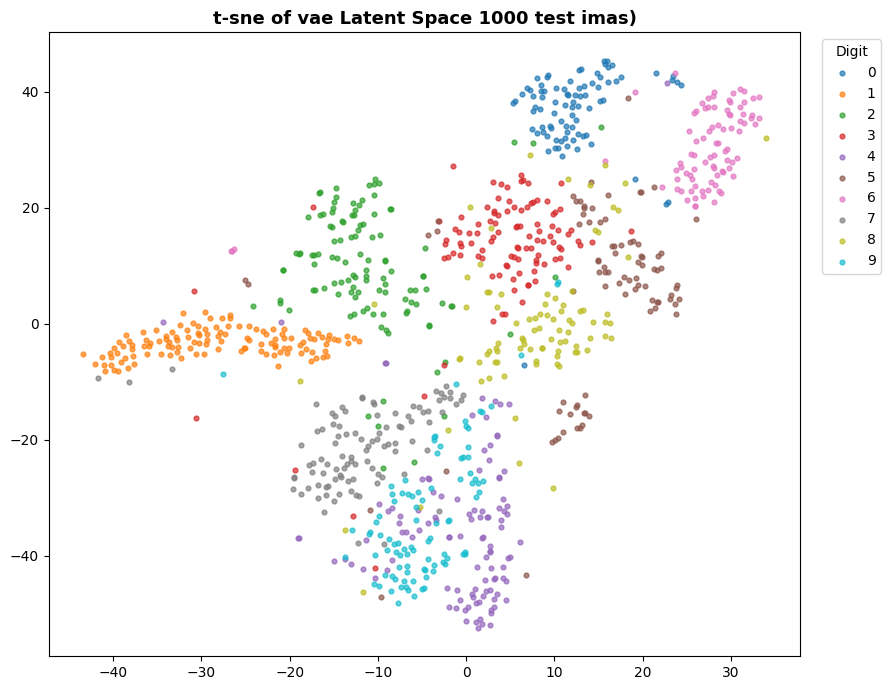

In [9]:
# ── t-SNE of latent space ─────────────────────────────────────────────────────
"""
TODO:
  1. Pass 1000 test images through vae.encode() to get mu vectors.
  2. Flatten each mu to a 1D vector (shape: 1000, LATENT_CH*7*7).
  3. Run TSNE(n_components=2) from sklearn.
  4. Scatter plot colored by digit class (use 10 distinct colors).
  5. Add a legend.
"""
# YOUR CODE HERE
vae.eval()
all_mu, all_labels = [], []
count = 0
with torch.no_grad():
    for x, y in test_loader:
        mu = vae.encode(x.to(device))
        all_mu.append(mu.cpu()); all_labels.append(y)
        count += x.shape[0]
        if count >= 1000: break

all_mu     = torch.cat(all_mu)[:1000].reshape(1000, -1).numpy()
all_labels = torch.cat(all_labels)[:1000].numpy()

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
embedding = tsne.fit_transform(all_mu)

colors10 = plt.cm.tab10(np.linspace(0, 1, 10))
plt.figure(figsize=(9, 7))
for cls in range(10):
    mask = all_labels == cls
    plt.scatter(embedding[mask, 0], embedding[mask, 1],
                c=[colors10[cls]], label=str(cls), s=12, alpha=0.7)
plt.legend(title='Digit', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.title('t-sne of vae Latent Space 1000 test imas)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('vae_tsne.png', dpi=100, bbox_inches='tight')
plt.show()

---
# C.2 — Latent Statistics and Normalization

Before training the diffusion model on latents, you must understand the latent distribution. Diffusion models assume data roughly in $[-1,1]$ or with unit variance — raw VAE latents often violate this.

**Your tasks:**
1. Extract all training latents $\{\mu_i\}$ from the frozen encoder.
2. Compute per-channel mean and std across the full training set.
3. Plot histograms of raw latent values per channel (one subplot per channel).
4. Define `normalize_latent(z)` and `denormalize_latent(z)` using the computed stats.
5. Plot histograms of normalized latents — verify they are approximately $\mathcal{N}(0,1)$.

In [10]:
@torch.no_grad()
def compute_latent_stats(vae, dataloader):
    """
    TODO: Compute per-channel mean and std of all training latents.

    Strategy:
      - Accumulate sum and sum-of-squares across the dataset.
      - Compute mean = sum / N, std = sqrt(sum_sq/N - mean^2).

    Returns:
        ch_mean: (LATENT_CH, 1, 1) tensor
        ch_std:  (LATENT_CH, 1, 1) tensor
    """
    # YOUR CODE HERE
    vae.eval()
    n_total   = 0
    ch_sum    = torch.zeros(LATENT_CH)
    ch_sum_sq = torch.zeros(LATENT_CH)

    for x, _ in dataloader:
        mu = vae.encode(x.to(device)).cpu()
        B  = mu.shape[0]
        mu_flat = mu.permute(0, 2, 3, 1).reshape(-1, LATENT_CH)
        ch_sum    += mu_flat.sum(dim=0)
        ch_sum_sq += (mu_flat ** 2).sum(dim=0)
        n_total   += mu_flat.shape[0]  # B * 49

    ch_mean = ch_sum / n_total
    ch_std  = torch.sqrt((ch_sum_sq / n_total) - ch_mean ** 2).clamp(min=1e-6)
    return ch_mean.reshape(LATENT_CH, 1, 1), ch_std.reshape(LATENT_CH, 1, 1)

latent_mean, latent_std = compute_latent_stats(vae, train_loader)
latent_mean = latent_mean.to(device)
latent_std  = latent_std.to(device)
print(f"Per-channel mean: {latent_mean.squeeze().cpu().numpy()}")
print(f"Per-channel std:  {latent_std.squeeze().cpu().numpy()}")


def normalize_latent(z):
    """TODO: Normalize z to approximately N(0,1) per channel."""
    # YOUR CODE HERE
    return (z - latent_mean) / latent_std

def denormalize_latent(z_norm):
    """TODO: Inverse of normalize_latent."""
    # YOUR CODE HERE
    return z_norm * latent_std + latent_mean

Per-channel mean: [-0.1315482   0.01829956  0.00764818 -0.08567852]
Per-channel std:  [1.0717607  0.74447954 0.81596    1.0502898 ]


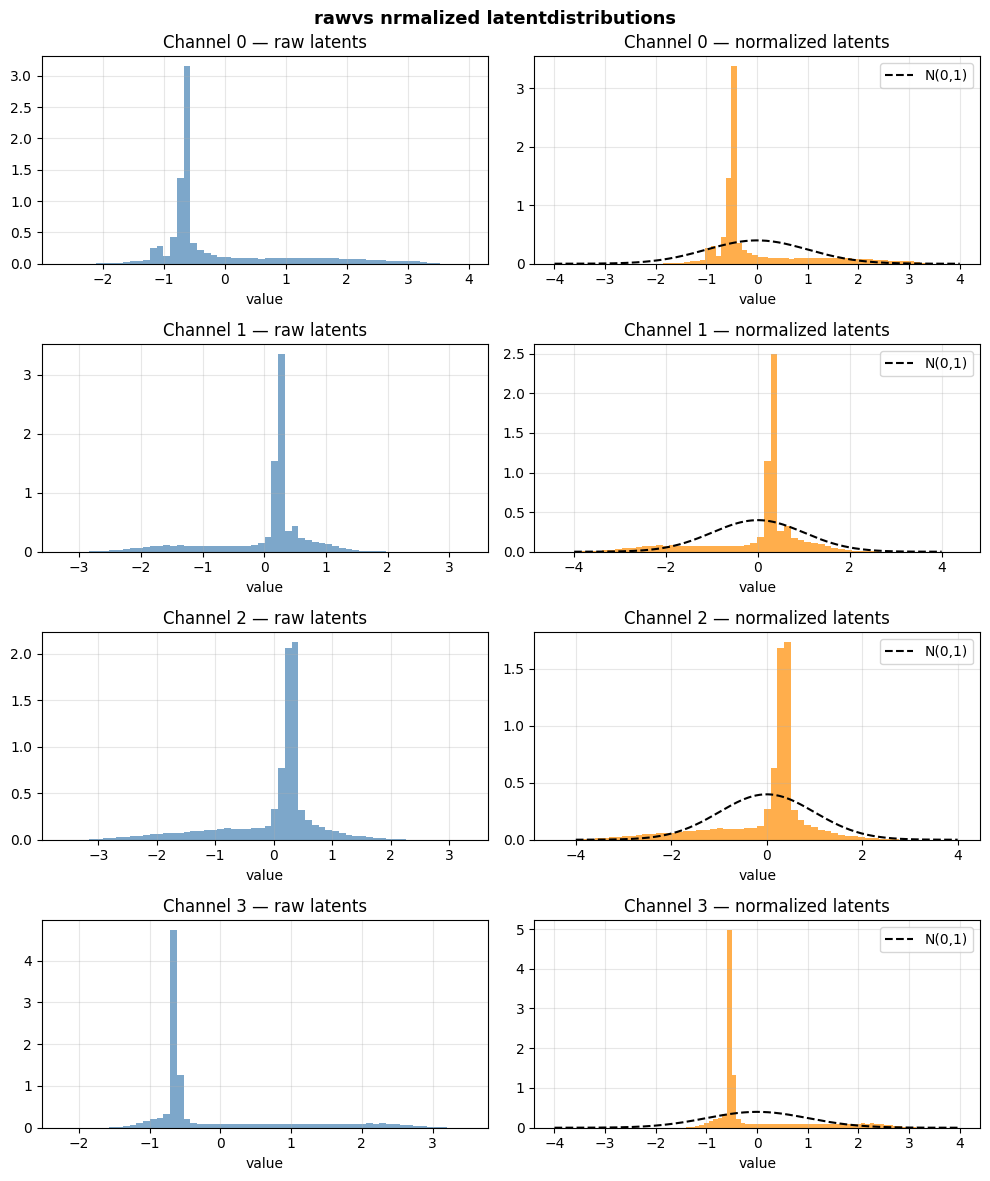

In [11]:
# ── Plot raw vs. normalized histograms ────────────────────────────────────────
"""
TODO: For each latent channel, plot:
  Left subplot:  histogram of raw latent values
  Right subplot: histogram of normalized latent values
Overlay a standard N(0,1) curve on the normalized histograms.
"""
# YOUR CODE HERE
vae.eval()
raw_latents = []
with torch.no_grad():
    for x, _ in test_loader:
        mu = vae.encode(x.to(device)).cpu()
        raw_latents.append(mu)
        if len(raw_latents) * x.shape[0] >= 2000: break
raw_latents = torch.cat(raw_latents)[:2000]  # (2000, 4, 7, 7)
norm_latents = ((raw_latents - latent_mean.cpu()) / latent_std.cpu())

fig, axes = plt.subplots(LATENT_CH, 2, figsize=(10, 3 * LATENT_CH))
xx = np.linspace(-4, 4, 200)
normal_curve = np.exp(-0.5 * xx**2) / np.sqrt(2 * np.pi)

for ch in range(LATENT_CH):
    raw_vals  = raw_latents[:, ch, :, :].flatten().numpy()
    norm_vals = norm_latents[:, ch, :, :].flatten().numpy()

    axes[ch, 0].hist(raw_vals,  bins=60, color='steelblue', density=True, alpha=0.7)
    axes[ch, 0].set_title(f'Channel {ch} — raw latents')
    axes[ch, 0].set_xlabel('value'); axes[ch, 0].grid(True, alpha=0.3)

    axes[ch, 1].hist(norm_vals, bins=60, color='darkorange', density=True, alpha=0.7)
    axes[ch, 1].plot(xx, normal_curve, 'k--', linewidth=1.5, label='N(0,1)')
    axes[ch, 1].set_title(f'Channel {ch} — normalized latents')
    axes[ch, 1].set_xlabel('value'); axes[ch, 1].legend(); axes[ch, 1].grid(True, alpha=0.3)

plt.suptitle('rawvs nrmalized latentdistributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('latent_histograms.png', dpi=100, bbox_inches='tight')
plt.show()


---
# C.3 — Class-Conditional Latent Diffusion Model

## Noise Schedule

Use the **cosine schedule** (Nichol & Dhariwal, 2021):
$$\bar{\alpha}_t = \frac{f(t)}{f(0)}, \quad f(t) = \cos\!\left(\frac{t/T + s}{1+s} \cdot \frac{\pi}{2}\right)^2, \quad s = 0.008$$
with $\beta_t = \text{clip}(1 - \bar{\alpha}_t/\bar{\alpha}_{t-1},\ 0,\ 0.999)$.

## Conditional U-Net Architecture

Your denoiser takes `(z_t, t, c)` and outputs predicted noise $\hat{\epsilon}$.

**Required components:**
1. **Sinusoidal timestep embedding** → projected through 2 linear layers (dim: `time_emb_dim`).
2. **Class embedding** via `nn.Embedding(num_classes + 1, class_emb_dim)` — index `num_classes` is the **null class** used for unconditional training.
3. **Combined conditioning:** concatenate or add time and class embeddings, then inject into each ResBlock.
4. **ResBlocks** with GroupNorm, SiLU, and conditioning injection.
5. **Self-attention** at the bottleneck.

## Classifier-Free Guidance (CFG)

During **training**, randomly drop the class label with probability $p_{\text{uncond}} = 0.15$, replacing it with the null class index. This trains the model to handle both conditional and unconditional inputs with a single network.

During **sampling**:
$$\hat{\epsilon} = \epsilon_\theta(z_t, t, \emptyset) + w \cdot \bigl(\epsilon_\theta(z_t, t, c) - \epsilon_\theta(z_t, t, \emptyset)\bigr)$$
where $w$ is the **guidance scale** and $\emptyset$ is the null class.

In [12]:
# ── Cosine noise schedule ──────────────────────────────────────────────────────
T = 1000

def cosine_beta_schedule(T, s=0.008):
    """
    TODO: Implement the cosine beta schedule.
    Returns a dict with keys:
      'betas', 'alphas', 'alpha_hats',
      'sqrt_alpha_hat', 'sqrt_one_minus_alpha_hat',
      'sqrt_recip_alpha', 'posterior_variance'
    All tensors of shape (T,) on CPU.
    """
    # YOUR CODE HERE
    steps      = torch.arange(T + 1, dtype=torch.float64)
    f          = torch.cos(((steps / T) + s) / (1 + s) * math.pi / 2) ** 2
    alpha_hats = (f / f[0]).float()
    betas      = torch.clamp(1 - alpha_hats[1:] / alpha_hats[:-1], 0, 0.999)
    alphas     = 1.0 - betas
    alpha_hats = torch.cumprod(alphas, dim=0)
    alpha_hats_prev = torch.cat([torch.tensor([1.0]), alpha_hats[:-1]])
    post_var   = torch.clamp(betas * (1 - alpha_hats_prev) / (1 - alpha_hats), min=1e-20)
    return {
        'betas':                 betas,
        'alphas':                alphas,
        'alpha_hats':            alpha_hats,
        'sqrt_alpha_hat':        torch.sqrt(alpha_hats),
        'sqrt_one_minus_alpha_hat': torch.sqrt(1.0 - alpha_hats),
        'sqrt_recip_alpha':      torch.sqrt(1.0 / alphas),
        'posterior_variance':    post_var,
        'alpha_hats_prev':       alpha_hats_prev,
    }


schedule = cosine_beta_schedule(T)
# Move all schedule tensors to device for later use
sched = {k: v.to(device) for k, v in schedule.items()}


def extract(a, t, x_shape):
    """Gather values from schedule tensor `a` at timesteps `t`, broadcast to x_shape."""
    out = a.gather(-1, t)
    return out.reshape(t.shape[0], *((1,) * (len(x_shape) - 1)))


def q_sample(x_0, t, noise=None):
    """
    TODO: Forward diffusion — add noise to x_0 at timestep t.
    Returns (x_t, noise).
    """
    # YOUR CODE HERE
    if noise is None:
        noise = torch.randn_like(x_0)
    sqrt_ahat   = extract(sched['sqrt_alpha_hat'], t, x_0.shape)
    sqrt_1mahat = extract(sched['sqrt_one_minus_alpha_hat'], t, x_0.shape)
    return sqrt_ahat * x_0 + sqrt_1mahat * noise, noise

In [13]:
# ── Building blocks ────────────────────────────────────────────────────────────

class SinusoidalEmbedding(nn.Module):
    """
    TODO: Sinusoidal timestep embedding followed by a 2-layer MLP.

    PE(t, 2i)   = sin(t / 10000^(2i/d))
    PE(t, 2i+1) = cos(t / 10000^(2i/d))

    Then: Linear(d, 4d) -> GELU -> Linear(4d, out_dim)
    """
    def __init__(self, dim, out_dim):
        super().__init__()
        # YOUR CODE HERE
        self.dim = dim
        self.mlp = nn.Sequential(
            nn.Linear(dim, dim * 4),
            nn.GELU(),
            nn.Linear(dim * 4, out_dim),
        )

    def forward(self, t):
        # t: (B,) integer timesteps
        # YOUR CODE HERE
        device   = t.device
        half     = self.dim // 2
        freqs    = torch.exp(-math.log(10000) * torch.arange(half, device=device) / (half - 1))
        args     = t[:, None].float() * freqs[None]
        emb      = torch.cat([args.sin(), args.cos()], dim=-1)
        return self.mlp(emb)


class ResBlock(nn.Module):
    """
    TODO: Residual block with conditioning injection.

    Structure:
      GroupNorm -> SiLU -> Conv2d
      (add projected cond_emb here)
      GroupNorm -> SiLU -> Conv2d
      + residual projection if in_ch != out_ch

    cond_dim: dimensionality of the combined (time + class) embedding.
    """
    def __init__(self, in_ch, out_ch, cond_dim, groups=4):
        super().__init__()
        # YOUR CODE HERE
        self.norm1     = nn.GroupNorm(groups, in_ch)
        self.act1      = nn.SiLU()
        self.conv1     = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.cond_proj = nn.Sequential(nn.SiLU(), nn.Linear(cond_dim, out_ch))
        self.norm2     = nn.GroupNorm(groups, out_ch)
        self.act2      = nn.SiLU()
        self.conv2     = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.res_conv  = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x, cond):
        # cond: (B, cond_dim) — add projected version to spatial features
        # YOUR CODE HERE
        h = self.conv1(self.act1(self.norm1(x)))
        h = h + self.cond_proj(cond)[:, :, None, None]
        h = self.conv2(self.act2(self.norm2(h)))
        return h + self.res_conv(x)


class SelfAttention2D(nn.Module):
    """
    TODO: Multi-head self-attention for 2D feature maps.
    Reshape (B, C, H, W) -> (B, H*W, C), apply attention, reshape back.
    Use pre-norm (GroupNorm before attention).
    """
    def __init__(self, dim, num_heads=4):
        super().__init__()
        # YOUR CODE HERE
        self.norm = nn.GroupNorm(1, dim)
        self.attn = nn.MultiheadAttention(dim, num_heads, batch_first=True)

    def forward(self, x):
        # YOUR CODE HERE
        B, C, H, W = x.shape
        h = self.norm(x).reshape(B, C, H * W).permute(0, 2, 1)
        h, _ = self.attn(h, h, h)
        return x + h.permute(0, 2, 1).reshape(B, C, H, W)

In [14]:
NUM_CLASSES  = 10
NULL_CLASS   = NUM_CLASSES   # index 10 = unconditional
COND_DIM     = 256           # combined time + class embedding dim

class ConditionalLatentUNet(nn.Module):
    """
    TODO: Class-conditional U-Net operating on (LATENT_CH, 7, 7) latents.

    Input:  z_t (B, LATENT_CH, 7, 7), t (B,), c (B,) class labels
    Output: predicted noise (B, LATENT_CH, 7, 7)

    Suggested architecture for 7x7 latents:
      - Initial conv: LATENT_CH -> 128
      - Encoder: [128 -> 128, 128 -> 256]  (with ResBlocks, no spatial downsampling
                                             since 7x7 is already small)
      - Bottleneck: ResBlock + SelfAttention2D + ResBlock
      - Decoder: [256+256 -> 128, 128+128 -> 128]  (skip connections via concat)
      - Output conv: 128 -> LATENT_CH

    Class conditioning:
      - nn.Embedding(NUM_CLASSES + 1, class_emb_dim)  [+1 for null class]
      - Project class_emb to COND_DIM, add to time_emb
      - Pass combined embedding to every ResBlock

    Note: since 7x7 is small, you may skip downsampling in the encoder
    and rely purely on the bottleneck attention for global context.
    """
    def __init__(self, latent_ch=LATENT_CH, base_ch=128, cond_dim=COND_DIM):
        super().__init__()
        # YOUR CODE HERE
        self.time_emb  = SinusoidalEmbedding(128, cond_dim // 2)
        self.class_emb = nn.Embedding(NUM_CLASSES + 1, cond_dim // 2)

        c1, c2 = base_ch, base_ch * 2

        self.stem  = nn.Conv2d(latent_ch, c1, 3, padding=1)
        self.enc1  = ResBlock(c1, c1, cond_dim)
        self.enc2  = ResBlock(c1, c2, cond_dim)

        self.mid1     = ResBlock(c2, c2, cond_dim)
        self.mid_attn = SelfAttention2D(c2, num_heads=4)
        self.mid2     = ResBlock(c2, c2, cond_dim)

        self.dec2 = ResBlock(c2 + c2, c1, cond_dim)
        self.dec1 = ResBlock(c1 + c1, c1, cond_dim)

        self.head = nn.Sequential(
            nn.GroupNorm(4, c1),
            nn.SiLU(),
            nn.Conv2d(c1, latent_ch, 1),
        )

    def forward(self, z, t, c=None):
        """
        z: (B, LATENT_CH, 7, 7)
        t: (B,) integer timesteps
        c: (B,) integer class labels, or None (treated as null class)
        """
        if c is None:
            c = torch.full((z.shape[0],), NULL_CLASS, dtype=torch.long, device=z.device)
        # YOUR CODE HERE
        t_emb   = self.time_emb(t)
        c_emb   = self.class_emb(c)
        cond    = torch.cat([t_emb, c_emb], dim=1)

        x1 = self.enc1(self.stem(z), cond)
        x2 = self.enc2(x1, cond)

        h = self.mid1(x2, cond)
        h = self.mid_attn(h)
        h = self.mid2(h, cond)

        h = self.dec2(torch.cat([h, x2], dim=1), cond)
        h = self.dec1(torch.cat([h, x1], dim=1), cond)

        return self.head(h)

In [15]:
# Sanity check
ldm_test = ConditionalLatentUNet().to(device)
z_test = torch.randn(4, LATENT_CH, 7, 7).to(device)
t_test = torch.randint(0, T, (4,)).to(device)
c_test = torch.randint(0, NUM_CLASSES, (4,)).to(device)
out = ldm_test(z_test, t_test, c_test)
assert out.shape == z_test.shape, f"Output shape mismatch: {out.shape}"
n_params = sum(p.numel() for p in ldm_test.parameters())
print(f"Model shape check passed. Parameters: {n_params:,}")

Model shape check passed. Parameters: 5,556,228


Epoch   1/30 | Loss: 0.2771
  -> Best LDM saved (loss=0.2771)
Epoch   2/30 | Loss: 0.1889
  -> Best LDM saved (loss=0.1889)
Epoch   3/30 | Loss: 0.1713
  -> Best LDM saved (loss=0.1713)
Epoch   4/30 | Loss: 0.1655
  -> Best LDM saved (loss=0.1655)
Epoch   5/30 | Loss: 0.1591
  -> Best LDM saved (loss=0.1591)
Epoch   6/30 | Loss: 0.1567
  -> Best LDM saved (loss=0.1567)
Epoch   7/30 | Loss: 0.1541
  -> Best LDM saved (loss=0.1541)
Epoch   8/30 | Loss: 0.1511
  -> Best LDM saved (loss=0.1511)
Epoch   9/30 | Loss: 0.1497
  -> Best LDM saved (loss=0.1497)
Epoch  10/30 | Loss: 0.1468
  -> Best LDM saved (loss=0.1468)
Epoch  11/30 | Loss: 0.1467
  -> Best LDM saved (loss=0.1467)
Epoch  12/30 | Loss: 0.1445
  -> Best LDM saved (loss=0.1445)
Epoch  13/30 | Loss: 0.1436
  -> Best LDM saved (loss=0.1436)
Epoch  14/30 | Loss: 0.1430
  -> Best LDM saved (loss=0.1430)
Epoch  15/30 | Loss: 0.1421
  -> Best LDM saved (loss=0.1421)
Epoch  16/30 | Loss: 0.1414
  -> Best LDM saved (loss=0.1414)
Epoch  1

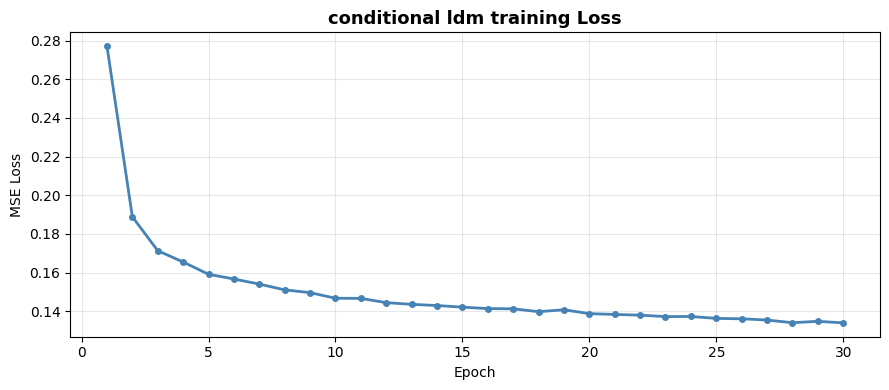

trcaining complete. Best loss: 0.1340


In [16]:
# ── LDM Training ──────────────────────────────────────────────────────────────
"""
TODO: Train the conditional LDM.

Training procedure:
  1. Freeze vae (no gradients through it).
  2. For each batch (x, labels):
       a. z_0 = vae.encode(x)           # deterministic latent
       b. z_0 = normalize_latent(z_0)   # normalize
       c. Sample t ~ Uniform[0, T-1]
       d. Sample eps ~ N(0, I)
       e. Compute z_t = q_sample(z_0, t, eps)
       f. With probability p_uncond=0.15, replace labels with NULL_CLASS
       g. eps_hat = model(z_t, t, labels)
       h. loss = MSE(eps, eps_hat)
  3. Optimizer: Adam, lr=2e-4
  4. Train for at least 30 epochs.
  5. Save best model as 'ldm_best.pt'.
  6. Plot training loss curve.
"""

LDM_EPOCHS  = 30
P_UNCOND    = 0.15

vae.eval()
for p in vae.parameters():
    p.requires_grad = False

ldm = ConditionalLatentUNet().to(device)
ldm_optimizer = Adam(ldm.parameters(), lr=2e-4)

# YOUR CODE HERE
best_ldm_loss = float('inf')
ldm_losses    = []

for epoch in range(LDM_EPOCHS):
    ldm.train()
    epoch_loss = 0.0

    for x, labels in train_loader:
        x, labels = x.to(device), labels.to(device)

        with torch.no_grad():
            z0 = vae.encode(x)
            z0 = normalize_latent(z0)

        t   = torch.randint(0, T, (x.shape[0],), device=device).long()
        eps = torch.randn_like(z0)
        z_t, _ = q_sample(z0, t, eps)
        mask   = torch.rand(labels.shape[0], device=device) < P_UNCOND
        labels_in = labels.clone()
        labels_in[mask] = NULL_CLASS

        eps_hat = ldm(z_t, t, labels_in)
        loss    = F.mse_loss(eps_hat, eps)

        ldm_optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(ldm.parameters(), 1.0)
        ldm_optimizer.step()
        epoch_loss += loss.item()

    avg = epoch_loss / len(train_loader)
    ldm_losses.append(avg)
    print(f"Epoch {epoch+1:3d}/{LDM_EPOCHS} | Loss: {avg:.4f}")

    if avg < best_ldm_loss:
        best_ldm_loss = avg
        torch.save(ldm.state_dict(), 'ldm_best.pt')
        print(f"  -> Best LDM saved (loss={best_ldm_loss:.4f})")

ldm.load_state_dict(torch.load('ldm_best.pt', map_location=device))
ldm.eval()

# Plot LDM loss curve
plt.figure(figsize=(9, 4))
plt.plot(range(1, LDM_EPOCHS+1), ldm_losses, marker='o', color='steelblue', linewidth=2, markersize=4)
plt.xlabel('Epoch'); plt.ylabel('MSE Loss')
plt.title('conditional ldm training Loss', fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3); plt.tight_layout()
plt.savefig('ldm_training_loss.png', dpi=100, bbox_inches='tight')
plt.show()
print(f"trcaining complete. Best loss: {best_ldm_loss:.4f}")


In [17]:
# ── Standard CFG sampling (baseline — used in later sections) ─────────────────

@torch.no_grad()
def p_sample_cfg(model, z_t, t_idx, class_label, guidance_scale=3.0):
    """
    TODO: One step of the DDPM reverse process with CFG.

    Steps:
      1. Run model twice: eps_uncond = model(z_t, t, null_class)
                          eps_cond   = model(z_t, t, class_label)
      2. Blend:  eps = eps_uncond + guidance_scale * (eps_cond - eps_uncond)
      3. Compute predicted z_0:
             z0_pred = (z_t - sqrt_one_minus_ahat * eps) / sqrt_ahat
      4. Compute posterior mean using z0_pred:
             mean = sqrt_ahat_prev * beta / (1 - ahat) * z0_pred
                  + sqrt_alpha * (1 - ahat_prev) / (1 - ahat) * z_t
      5. Add noise (sigma * eps_noise) if t_idx > 0, else return mean.

    Returns: z_{t-1}
    """
    # YOUR CODE HERE
    B = z_t.shape[0]
    t_batch = torch.full((B,), t_idx, device=device, dtype=torch.long)
    null_c  = torch.full((B,), NULL_CLASS, device=device, dtype=torch.long)

    eps_uncond = model(z_t, t_batch, null_c)
    eps_cond   = model(z_t, t_batch, class_label)
    eps        = eps_uncond + guidance_scale * (eps_cond - eps_uncond)

    sqrt_ahat   = extract(sched['sqrt_alpha_hat'], t_batch, z_t.shape)
    sqrt_1mahat = extract(sched['sqrt_one_minus_alpha_hat'], t_batch, z_t.shape)
    z0_pred     = (z_t - sqrt_1mahat * eps) / sqrt_ahat.clamp(min=1e-8)
    z0_pred     = z0_pred.clamp(-3, 3)

    ahat        = extract(sched['alpha_hats'], t_batch, z_t.shape)
    ahat_prev   = extract(sched['alpha_hats_prev'], t_batch, z_t.shape)
    beta        = extract(sched['betas'], t_batch, z_t.shape)
    alpha       = extract(sched['alphas'], t_batch, z_t.shape)

    mean = (torch.sqrt(ahat_prev) * beta / (1 - ahat)) * z0_pred +            (torch.sqrt(alpha) * (1 - ahat_prev) / (1 - ahat)) * z_t

    if t_idx > 0:
        post_var = extract(sched['posterior_variance'], t_batch, z_t.shape)
        mean = mean + torch.sqrt(post_var) * torch.randn_like(z_t)
    return mean



@torch.no_grad()
def sample_cfg(model, vae, class_label, n_samples=8, guidance_scale=3.0):
    """
    TODO: Full reverse process using p_sample_cfg.

    Steps:
      1. z_T ~ N(0, I), shape (n_samples, LATENT_CH, 7, 7)
      2. Loop t from T-1 to 0, calling p_sample_cfg at each step.
      3. Denormalize latent.
      4. Decode through vae.decode().
      5. Clip to [-1,1], rescale to [0,1].

    Returns: images (n_samples, 1, 28, 28)
    """
    # YOUR CODE HERE
    c_tensor = torch.full((n_samples,), class_label, dtype=torch.long, device=device)
    z = torch.randn(n_samples, LATENT_CH, 7, 7, device=device)

    for t_idx in reversed(range(T)):
        z = p_sample_cfg(model, z, t_idx, c_tensor, guidance_scale)

    z = denormalize_latent(z)
    imgs = vae.decode(z).clamp(-1, 1)
    return (imgs + 1) / 2.0

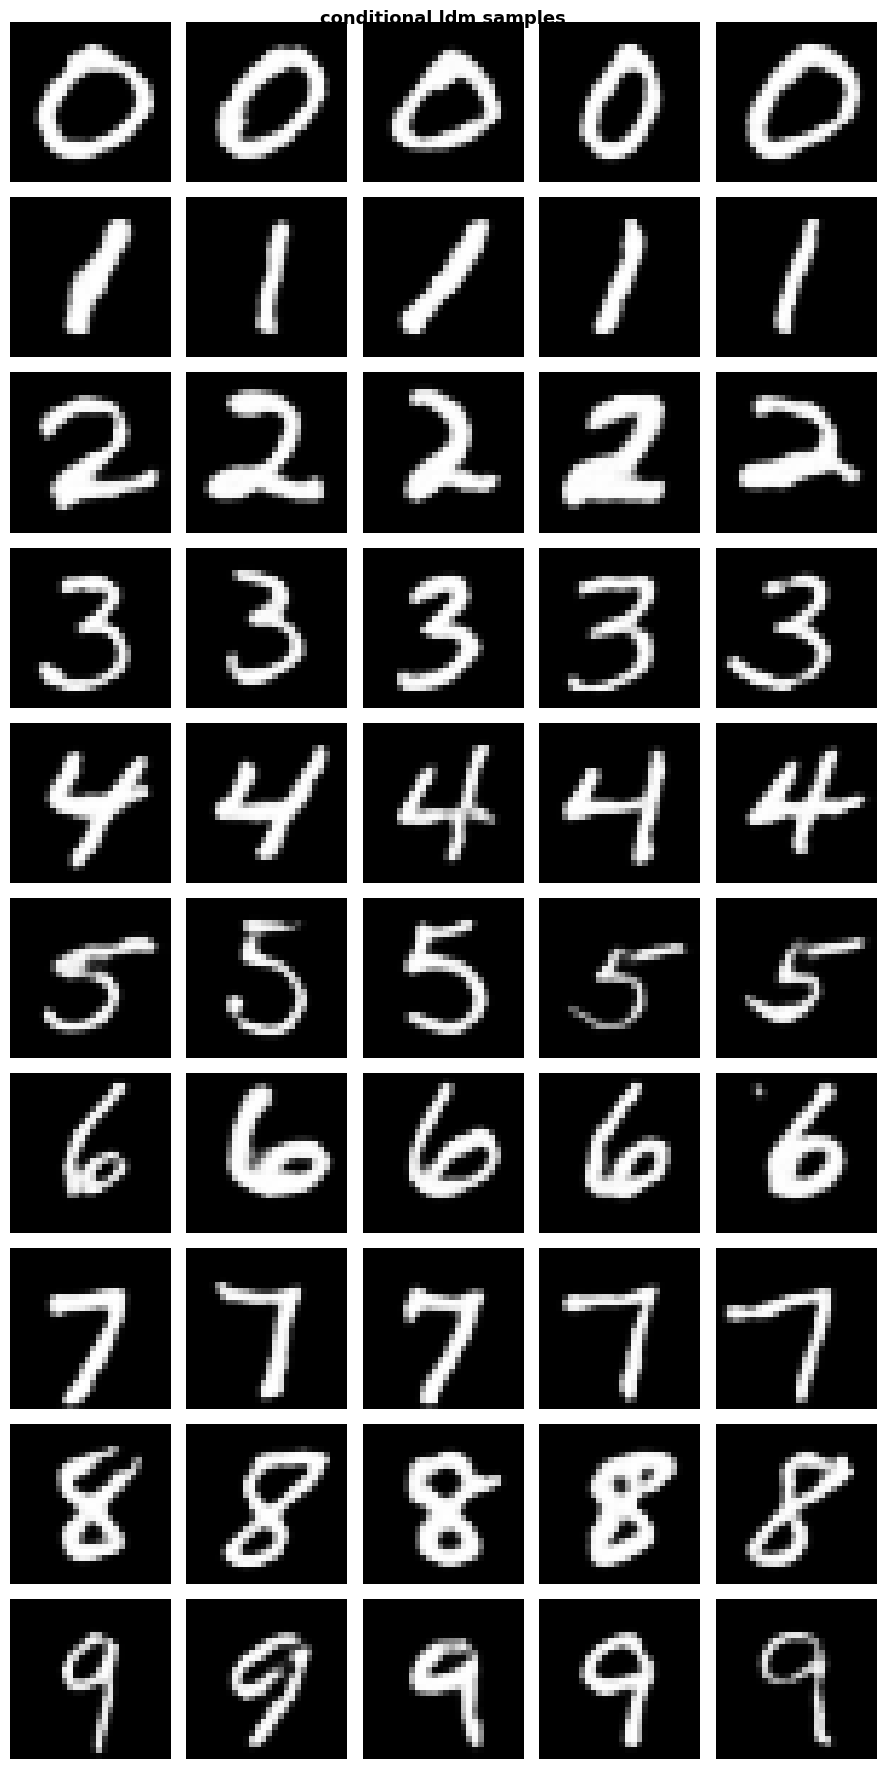

In [18]:
# ── Generate baseline samples ─────────────────────────────────────────────────
"""
TODO:
  1. Generate 5 samples for each digit class (0-9) using guidance_scale=3.0.
  2. Display in a 10x5 grid (rows = classes, cols = samples).
  3. Add row labels showing the digit class.
"""
# YOUR CODE HERE
ldm.eval()
n_per_class = 5
fig, axes = plt.subplots(10, n_per_class, figsize=(n_per_class * 1.8, 10 * 1.8))

for cls in range(10):
    imgs = sample_cfg(ldm, vae, class_label=cls, n_samples=n_per_class, guidance_scale=3.0)
    for col in range(n_per_class):
        axes[cls, col].imshow(imgs[col].squeeze().cpu().numpy(), cmap='gray', vmin=0, vmax=1)
        axes[cls, col].axis('off')
    axes[cls, 0].set_ylabel(f'Digit {cls}', fontsize=9, rotation=0, labelpad=40, va='center')

plt.suptitle('conditional ldm samples', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('ldm_baseline_samples.png', dpi=100, bbox_inches='tight')
plt.show()

---
# C.4 — Understanding Latent Drift

## What is Cache Misalignment / Offset Drift?

**Reading:** Before continuing, read Section IV (Method) of the AdaCorrection paper (Liu et al., 2026, arXiv:2602.13357), provided separately. Pay close attention to the definitions of temporal deviation (Eq. 1), spatial variation (Eq. 2), and the offset score (Eq. 3).

In iterative diffusion sampling, hidden states at each denoising step are highly redundant across consecutive timesteps — the content changes slowly. This motivates **caching** activations to skip recomputation. However, when a cached (stale) activation $\tilde{h}^\ell_t$ is reused instead of the freshly computed $h^\ell_t$, a **cache misalignment error** accumulates across layers and timesteps:

$$\|h^{\ell+1}_t - \tilde{h}^{\ell+1}_t\|_2 \leq L \cdot \tau \cdot S^\ell_t$$

where $L$ is the Lipschitz constant of the block, $\tau$ is the cache lag (how many steps ago it was cached), and $S^\ell_t$ is the **offset score** — a lightweight misalignment signal.

In this section you will adapt the AdaCorrection OEM (Offset Estimation Module) to the latent diffusion setting, measuring drift in the **denoiser's hidden states** rather than Transformer layer activations.

## Offset Score for Latent Diffusion

We adapt Equations (1)–(3) from AdaCorrection to operate on the denoiser's predicted noise $\hat{\epsilon}_t$, which serves as a proxy for the hidden state at the final layer.

**Temporal deviation** — how much the predicted noise changed since the previous step:
$$\Delta^\text{temp}(t) = \frac{1}{B \cdot P} \sum_{b,i} \|\hat{\epsilon}_t[b,i] - \hat{\epsilon}_{t+1}[b,i]\|_2^2$$
where $i$ indexes spatial positions (flattened $7 \times 7$ patches) and $b$ indexes the batch.

**Spatial variation** — channel-wise dispersion within the current prediction:
$$\Delta^\text{spatial}(t) = \frac{1}{B \cdot P} \sum_{b,i} \text{Var}_d(\hat{\epsilon}_t[b,i,d])$$

**Total offset score:**
$$S_t = \Delta^\text{temp}(t)^2 + \lambda_{\text{sp}} \cdot \Delta^\text{spatial}(t)^2$$
with spatial weighting $\lambda_{\text{sp}} = 1.0$ (matching AdaCorrection's default).

In [19]:
# ── OEM: Offset Estimation Module ─────────────────────────────────────────────

def oem_temporal_deviation(eps_t, eps_prev):
    """
    TODO: Compute temporal deviation between current and previous noise predictions.
    Implements Eq. (1) from AdaCorrection, adapted for (B, C, H, W) tensors.

    eps_t:    (B, LATENT_CH, 7, 7) — predicted noise at current step t
    eps_prev: (B, LATENT_CH, 7, 7) — predicted noise at previous step t+1
              (or zeros if no previous step is available)

    Steps:
      1. Reshape both to (B, P, C) where P = 7*7 = 49 patches.
      2. Compute per-patch L2 norm of the difference: ||eps_t[b,i,:] - eps_prev[b,i,:]||_2^2
      3. Average over B and P.

    Returns: scalar tensor
    """
    # YOUR CODE HERE
    B, C, H, W = eps_t.shape
    P = H * W
    a = eps_t.reshape(B, P, C)
    b = eps_prev.reshape(B, P, C)
    return ((a - b) ** 2).sum(dim=-1).mean()


def oem_spatial_variation(eps_t):
    """
    TODO: Compute spatial variation (channel-wise dispersion) of the noise prediction.
    Implements Eq. (2) from AdaCorrection.

    eps_t: (B, LATENT_CH, 7, 7)

    Steps:
      1. Reshape to (B, P, C) where P = 49.
      2. Compute variance over the channel dim d for each patch: Var_d(eps_t[b,i,d])
      3. Average over B and P.

    Returns: scalar tensor
    """
    # YOUR CODE HERE
    B, C, H, W = eps_t.shape
    P = H * W
    patches = eps_t.reshape(B, P, C)
    var = patches.var(dim=-1)
    return var.mean()


def oem_offset_score(eps_t, eps_prev, lambda_sp=1.0):
    """
    TODO: Compute the total offset score S_t (Eq. 3 from AdaCorrection).

    S_t = delta_temp^2 + lambda_sp * delta_spatial^2

    Returns: scalar tensor
    """
    # YOUR CODE HERE
    delta_temp    = oem_temporal_deviation(eps_t, eps_prev)
    delta_spatial = oem_spatial_variation(eps_t)
    return delta_temp ** 2 + lambda_sp * delta_spatial ** 2, delta_temp, delta_spatial

In [20]:
# ── Measure offset scores during a full reverse pass ──────────────────────────

def predict_z0_from_zt(z_t, t_idx, eps_hat):
    """
    TODO: Recover predicted z_0 from z_t and eps_hat.
    z0_hat = (z_t - sqrt(1 - alpha_hat_t) * eps_hat) / sqrt(alpha_hat_t)
    Clamp to [-3, 3].
    """
    # YOUR CODE HERE
    t_batch     = torch.full((z_t.shape[0],), t_idx, device=device, dtype=torch.long)
    sqrt_ahat   = extract(sched['sqrt_alpha_hat'], t_batch, z_t.shape)
    sqrt_1mahat = extract(sched['sqrt_one_minus_alpha_hat'], t_batch, z_t.shape)
    z0 = (z_t - sqrt_1mahat * eps_hat) / sqrt_ahat.clamp(min=1e-8)
    return z0.clamp(-3, 3)


@torch.no_grad()
def measure_offset_drift(model, target_class, guidance_scale=3.0,
                          n_samples=4, record_every=20):
    """
    TODO: Run the full reverse diffusion process and record OEM signals.

    At every `record_every` steps, record:
      - S_t:              total offset score (scalar)
      - delta_temp:       temporal deviation component
      - delta_spatial:    spatial variation component
      - z0_pred:          current predicted z_0 (for filmstrip visualization)

    Also record the final decoded images.

    Returns dict with keys:
      'timesteps', 'S_t', 'delta_temp', 'delta_spatial',
      'z0_preds' (list of tensors), 'final_images'
    """
    model.eval()
    c_tensor  = torch.full((n_samples,), target_class, dtype=torch.long, device=device)
    null_c    = torch.full((n_samples,), NULL_CLASS, dtype=torch.long, device=device)
    z         = torch.randn(n_samples, LATENT_CH, 7, 7, device=device)
    eps_prev  = torch.zeros_like(z)

    timesteps_rec, S_t_rec, dt_rec, ds_rec, z0_preds = [], [], [], [], []

    for t_idx in reversed(range(T)):
        t_batch    = torch.full((n_samples,), t_idx, device=device, dtype=torch.long)
        eps_uncond = model(z, t_batch, null_c)
        eps_cond   = model(z, t_batch, c_tensor)
        eps_hat    = eps_uncond + guidance_scale * (eps_cond - eps_uncond)

        S_t, dt, ds = oem_offset_score(eps_hat, eps_prev.to(device))

        if t_idx % record_every == 0:
            z0_pred = predict_z0_from_zt(z, t_idx, eps_hat)
            z0_dec  = denormalize_latent(z0_pred)
            z0_img  = vae.decode(z0_dec).clamp(-1, 1)
            z0_preds.append(((z0_img + 1) / 2.0).cpu())
            timesteps_rec.append(t_idx)
            S_t_rec.append(S_t.item())
            dt_rec.append(dt.item())
            ds_rec.append(ds.item())

        eps_prev = eps_hat.cpu()
        z = p_sample_cfg(model, z, t_idx, c_tensor, guidance_scale)
    final_z   = denormalize_latent(z)
    final_imgs = ((vae.decode(final_z).clamp(-1, 1) + 1) / 2.0).cpu()

    return {
        'timesteps':     timesteps_rec,
        'S_t':           S_t_rec,
        'delta_temp':    dt_rec,
        'delta_spatial': ds_rec,
        'z0_preds':      z0_preds,
        'final_images':  final_imgs,
    }


Measuring class 2...
Measuring class 5...
Measuring class 8...


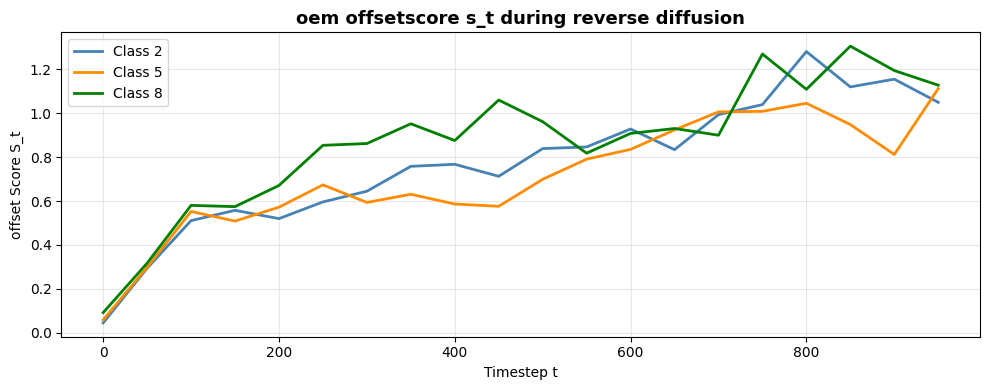

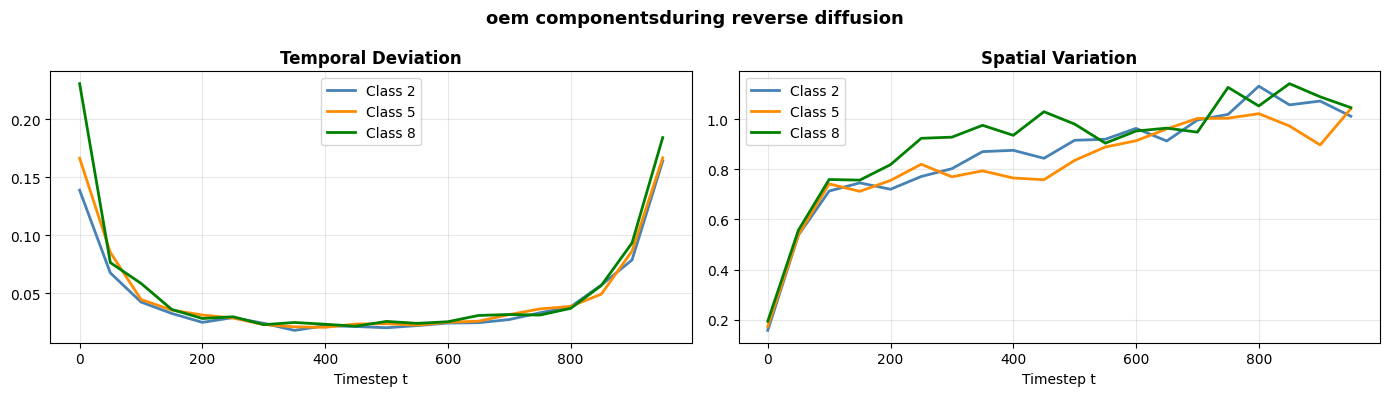

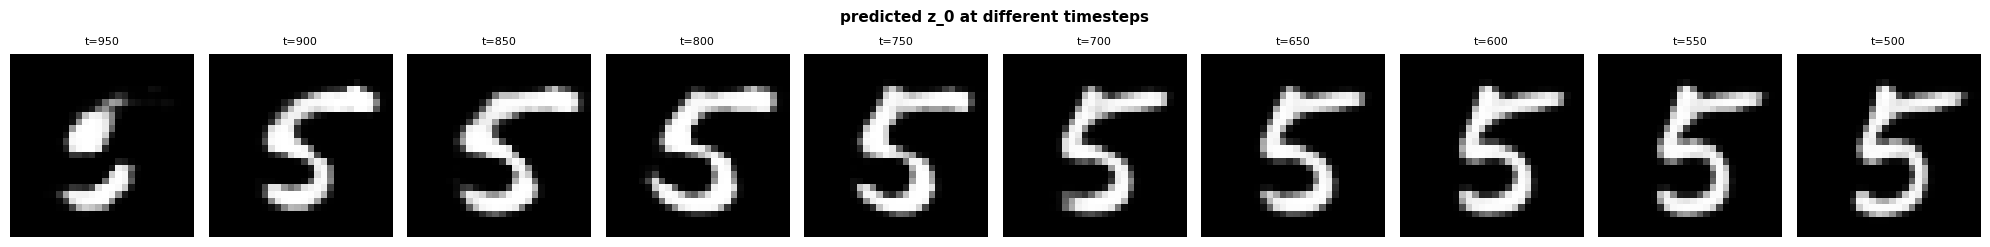

In [21]:
# ── Visualize OEM signals for 3 classes ───────────────────────────────────────
"""
TODO:
  1. Call measure_offset_drift for classes 2, 5, and 8 (guidance_scale=3.0).
  2. Plot all three offset score curves S_t vs timestep on one figure.
  3. On a second figure with two subplots, compare delta_temp and delta_spatial
     separately — do they peak at the same timesteps?
  4. Display z0_preds as a filmstrip for one class (one row, columns = timesteps).
     Observe how the predicted image forms and then stabilizes.
"""
# YOUR CODE HERE
import gc
drift_results = {}
for cls in [2, 5, 8]:
    gc.collect()
    torch.cuda.empty_cache()
    print(f"Measuring class {cls}...")
    drift_results[cls] = measure_offset_drift(ldm, target_class=cls,
                                               guidance_scale=3.0, n_samples=2,
                                               record_every=50)

# Plot 1: S_t curves
plt.figure(figsize=(10, 4))
colors = ['steelblue', 'darkorange', 'green']
for (cls, col) in zip([2, 5, 8], colors):
    r = drift_results[cls]
    ts = list(reversed(r['timesteps']))
    st = list(reversed(r['S_t']))
    plt.plot(ts, st, label=f'Class {cls}', color=col, linewidth=2)
plt.xlabel('Timestep t'); plt.ylabel('offset Score S_t')
plt.title('oem offsetscore s_t during reverse diffusion', fontsize=13, fontweight='bold')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
plt.savefig('oem_St_curves.png', dpi=100, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for (cls, col) in zip([2, 5, 8], colors):
    r = drift_results[cls]
    ts = list(reversed(r['timesteps']))
    axes[0].plot(ts, list(reversed(r['delta_temp'])),    label=f'Class {cls}', color=col, linewidth=2)
    axes[1].plot(ts, list(reversed(r['delta_spatial'])), label=f'Class {cls}', color=col, linewidth=2)
for ax, title in zip(axes, ['Temporal Deviation', 'Spatial Variation']):
    ax.set_xlabel('Timestep t'); ax.set_title(title, fontweight='bold')
    ax.legend(); ax.grid(True, alpha=0.3)
plt.suptitle('oem componentsduring reverse diffusion', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig('oem_components.png', dpi=100, bbox_inches='tight'); plt.show()

r5 = drift_results[5]
n_frames = min(len(r5['z0_preds']), 10)
fig, axes = plt.subplots(1, n_frames, figsize=(n_frames * 2, 2.5))
for i in range(n_frames):
    img = r5['z0_preds'][i][0].squeeze().numpy()
    axes[i].imshow(img, cmap='gray', vmin=0, vmax=1)
    axes[i].set_title(f"t={r5['timesteps'][i]}", fontsize=8)
    axes[i].axis('off')
plt.suptitle('predicted z_0 at different timesteps', fontsize=11, fontweight='bold')
plt.tight_layout(); plt.savefig('z0_filmstrip.png', dpi=100, bbox_inches='tight'); plt.show()


---
# C.5 — AdaCorrection: Adaptive Offset Cache Correction

## Reference
This section is a direct implementation of the **AdaCorrection** framework (Liu et al., 2026). Read Sections IV.C (OEM) and IV.D (ACM) of the paper carefully before proceeding. The equations referenced below are numbered as in the paper.

## ACM: Adaptive Correction Module

Given the offset score $S_t$ from the OEM, the ACM computes a **correction weight** $\lambda_t \in [0, 1]$ that governs how much fresh computation is blended back in:

$$\lambda_t = \text{clip}(\gamma \cdot S_t,\ 0,\ 1) \quad \text{(Eq. 6)}$$

where $\gamma$ is the **sensitivity parameter**. The paper's ablation (Table IV) shows $\gamma = 1.0$ is optimal.

The corrected activation is:
$$\hat{h}^{\ell+1}_t = (1 - \lambda_t) \cdot \tilde{h}^{\ell+1}_t + \lambda_t \cdot h^{\ell+1}_t \quad \text{(Eq. 7)}$$

where $\tilde{h}^{\ell+1}_t$ is the cached (stale) result and $h^{\ell+1}_t$ is freshly computed.

## Adapting ACM to Latent Diffusion Sampling

In full DiTs, caching happens at the Transformer layer level. In our simpler latent U-Net, we **cache the predicted noise** $\hat{\epsilon}$ and apply ACM at the **sampling step** level:

- **Cached prediction:** $\tilde{\epsilon}_t$ — the noise prediction from $\tau$ steps ago (reused without recomputation).
- **Fresh prediction:** $\hat{\epsilon}_t$ — the noise prediction from a full forward pass at step $t$.
- **Corrected prediction:** $\hat{\epsilon}^{\text{corr}}_t = (1 - \lambda_t) \cdot \tilde{\epsilon}_t + \lambda_t \cdot \hat{\epsilon}_t$

When $\lambda_t \approx 0$: the cache is valid, reuse it (fast).  
When $\lambda_t \approx 1$: large drift detected, recompute fully (accurate).

This is the **Pareto trade-off** described in the paper: larger $\gamma$ → higher quality, higher compute cost.

In [22]:
# ── ACM: Adaptive Correction Module ───────────────────────────────────────────

def acm_correction_weight(S_t, gamma=1.0):
    """
    TODO: Compute correction weight lambda_t (Eq. 6 from AdaCorrection).

    lambda_t = clip(gamma * S_t, 0, 1)

    Args:
        S_t:   scalar tensor — offset score from OEM
        gamma: sensitivity parameter (default 1.0 per paper's ablation)

    Returns: lambda_t as a scalar tensor in [0, 1]
    """
    # YOUR CODE HERE
    return torch.clamp(gamma * S_t, 0.0, 1.0)


def acm_blend(eps_cached, eps_fresh, lambda_t):
    """
    TODO: Blend cached and fresh noise predictions (Eq. 7 from AdaCorrection).

    eps_corrected = (1 - lambda_t) * eps_cached + lambda_t * eps_fresh

    Args:
        eps_cached: (B, LATENT_CH, 7, 7) — reused prediction from tau steps ago
        eps_fresh:  (B, LATENT_CH, 7, 7) — freshly computed prediction
        lambda_t:   scalar correction weight from acm_correction_weight

    Returns: eps_corrected (B, LATENT_CH, 7, 7)
    """
    # YOUR CODE HERE
    return (1 - lambda_t) * eps_cached + lambda_t * eps_fresh

In [23]:
@torch.no_grad()
def sample_with_adacorrection(model, vae, target_class,
                               guidance_scale=3.0, n_samples=4,
                               cache_lag=5, gamma=1.0, lambda_sp=1.0):
    import gc
    gc.collect()
    torch.cuda.empty_cache()
    model.eval()
    c_tensor      = torch.full((n_samples,), target_class, dtype=torch.long, device=device)
    null_c        = torch.full((n_samples,), NULL_CLASS,   dtype=torch.long, device=device)
    z             = torch.randn(n_samples, LATENT_CH, 7, 7, device=device)
    cache         = {}
    eps_prev_step = torch.zeros(n_samples, LATENT_CH, 7, 7)  # kept on CPU
    S_t_curve     = []
    lambda_curve  = []
    reuse_count   = 0

    for t_idx in reversed(range(T)):
        t_batch    = torch.full((n_samples,), t_idx, device=device, dtype=torch.long)
        eps_uncond = model(z, t_batch, null_c)
        eps_cond   = model(z, t_batch, c_tensor)
        eps_fresh  = eps_uncond + guidance_scale * (eps_cond - eps_uncond)

        # retrieve cached — move to GPU only briefly
        cache_key = t_idx + cache_lag
        eps_cached = cache[cache_key].to(device) if cache_key in cache else eps_fresh

        # OEM — move eps_prev to GPU only for this call
        S_t, dt, ds = oem_offset_score(eps_fresh, eps_prev_step.to(device), lambda_sp)

        # ACM
        lambda_t      = acm_correction_weight(S_t, gamma)
        eps_corrected = acm_blend(eps_cached, eps_fresh, lambda_t)

        S_t_curve.append((t_idx, S_t.item()))
        lambda_curve.append((t_idx, lambda_t.item()))
        if lambda_t.item() < 0.5:
            reuse_count += 1

        # store everything on CPU
        cache[t_idx]  = eps_fresh.detach().cpu()
        eps_prev_step = eps_fresh.detach().cpu()

        # DDPM reverse step
        sqrt_ahat   = extract(sched['sqrt_alpha_hat'],           t_batch, z.shape)
        sqrt_1mahat = extract(sched['sqrt_one_minus_alpha_hat'], t_batch, z.shape)
        z0_pred     = (z - sqrt_1mahat * eps_corrected) / sqrt_ahat.clamp(min=1e-8)
        z0_pred     = z0_pred.clamp(-3, 3)

        ahat      = extract(sched['alpha_hats'],         t_batch, z.shape)
        ahat_prev = extract(sched['alpha_hats_prev'],    t_batch, z.shape)
        beta      = extract(sched['betas'],              t_batch, z.shape)
        alpha     = extract(sched['alphas'],             t_batch, z.shape)
        mean      = (torch.sqrt(ahat_prev) * beta / (1 - ahat)) * z0_pred + \
                    (torch.sqrt(alpha) * (1 - ahat_prev) / (1 - ahat)) * z

        if t_idx > 0:
            post_var = extract(sched['posterior_variance'], t_batch, z.shape)
            z = mean + torch.sqrt(post_var) * torch.randn_like(z)
        else:
            z = mean

        # free intermediate tensors
        del eps_uncond, eps_cond, eps_fresh, eps_corrected, eps_cached

    z    = denormalize_latent(z)
    imgs = ((vae.decode(z).clamp(-1, 1) + 1) / 2.0).cpu()
    hit_rate = reuse_count / T
    return imgs, S_t_curve, lambda_curve, hit_rate


Running baseline...
  Running: AdaCorrection lag=5 γ=1.0
    Hit rate: 0.081
  Running: AdaCorrection lag=10 γ=1.0
    Hit rate: 0.042
  Running: AdaCorrection lag=5 γ=0.5
    Hit rate: 0.790
  Running: AdaCorrection lag=5 γ=2.0
    Hit rate: 0.004


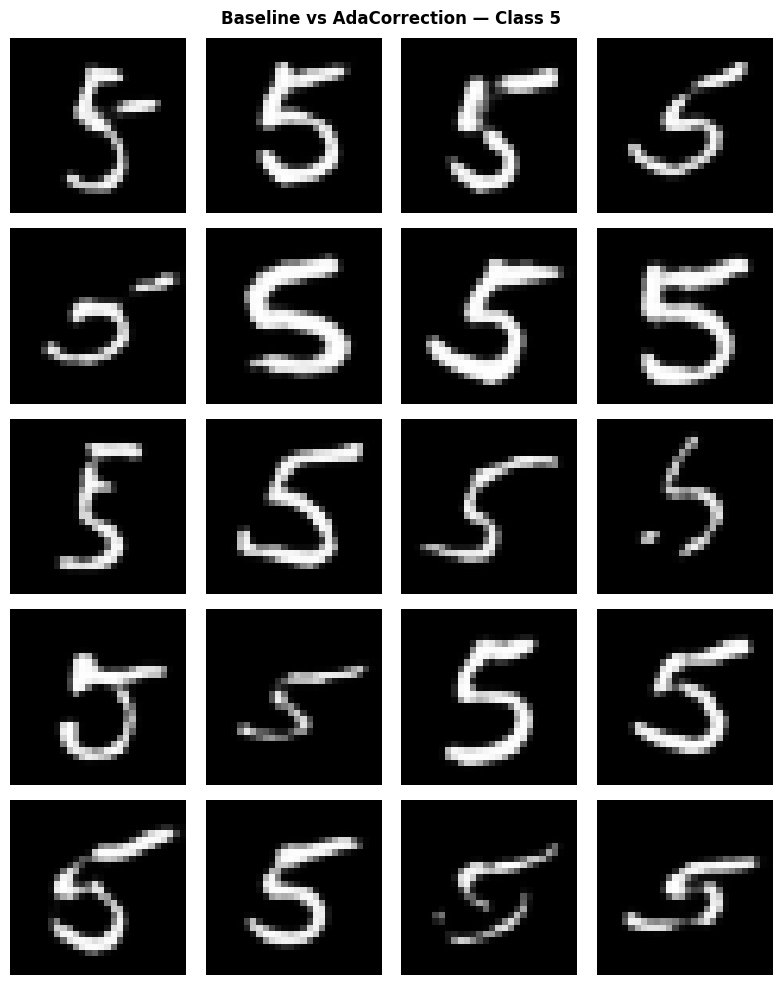

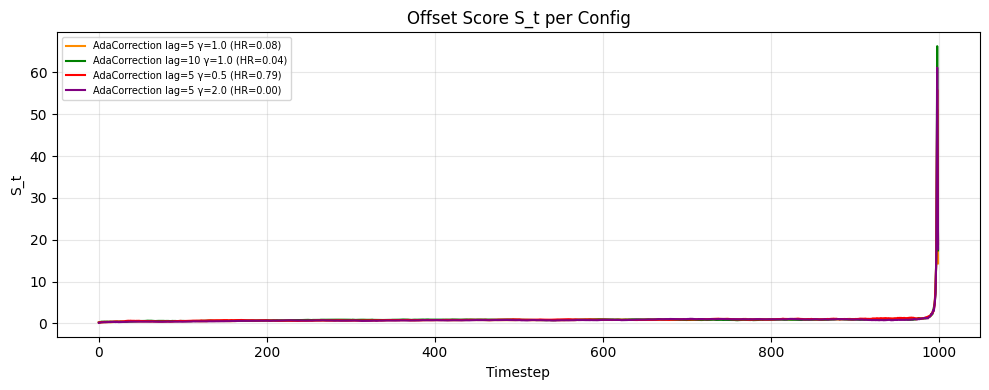

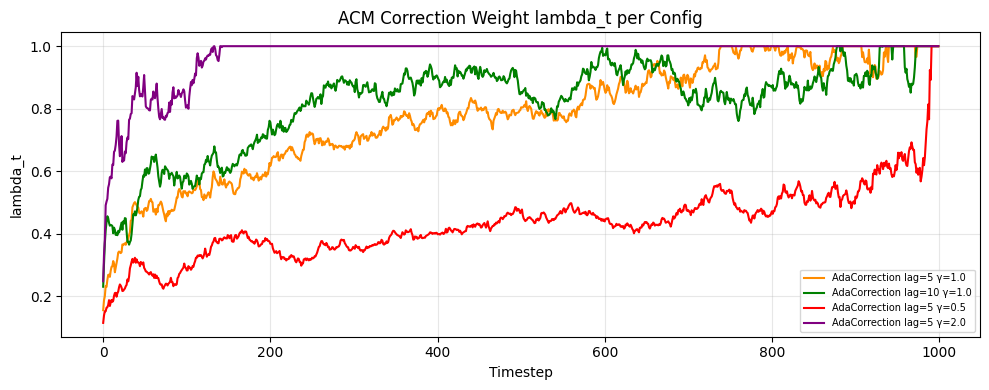


Hit rates:
  AdaCorrection lag=5 γ=1.0: 0.081
  AdaCorrection lag=10 γ=1.0: 0.042
  AdaCorrection lag=5 γ=0.5: 0.790
  AdaCorrection lag=5 γ=2.0: 0.004


In [24]:
import gc
gc.collect()
torch.cuda.empty_cache()

target_cls = 5
n_samp     = 4   # reduced from 8 to save GPU memory
guidance   = 3.0

configs = [
    ('Baseline (full recompute)',  None),
    ('AdaCorrection lag=5 γ=1.0',  dict(cache_lag=5,  gamma=1.0)),
    ('AdaCorrection lag=10 γ=1.0', dict(cache_lag=10, gamma=1.0)),
    ('AdaCorrection lag=5 γ=0.5',  dict(cache_lag=5,  gamma=0.5)),
    ('AdaCorrection lag=5 γ=2.0',  dict(cache_lag=5,  gamma=2.0)),
]

all_imgs   = []
ada_curves = []

print("Running baseline...")
baseline_imgs = sample_cfg(ldm, vae, class_label=target_cls,
                            n_samples=n_samp, guidance_scale=guidance)
all_imgs.append(baseline_imgs.cpu())
gc.collect(); torch.cuda.empty_cache()

for name, kwargs in configs[1:]:
    print(f"  Running: {name}")
    gc.collect(); torch.cuda.empty_cache()
    imgs, S_curve, L_curve, hr = sample_with_adacorrection(
        ldm, vae, target_class=target_cls,
        guidance_scale=guidance, n_samples=n_samp, **kwargs)
    all_imgs.append(imgs)
    ada_curves.append((name, S_curve, L_curve, hr))
    print(f"    Hit rate: {hr:.3f}")
    gc.collect(); torch.cuda.empty_cache()

# Image grid
fig, axes = plt.subplots(5, n_samp, figsize=(n_samp * 2, 5 * 2))
for row, (cfg_name, _) in enumerate(configs):
    imgs = all_imgs[row]
    for col in range(n_samp):
        axes[row, col].imshow(imgs[col].squeeze().numpy(), cmap='gray', vmin=0, vmax=1)
        axes[row, col].axis('off')
    axes[row, 0].set_ylabel(cfg_name, fontsize=7, rotation=0, labelpad=120, va='center')
plt.suptitle(f'Baseline vs AdaCorrection — Class {target_cls}', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('adacorrection_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

# S_t curves
plt.figure(figsize=(10, 4))
cols = ['darkorange', 'green', 'red', 'purple']
for (name, S_curve, _, hr), col in zip(ada_curves, cols):
    ts = [x[0] for x in S_curve]
    st = [x[1] for x in S_curve]
    plt.plot(ts, st, label=f'{name} (HR={hr:.2f})', color=col, linewidth=1.5)
plt.xlabel('Timestep'); plt.ylabel('S_t')
plt.title('Offset Score S_t per Config')
plt.legend(fontsize=7); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('adacorrection_St.png', dpi=100, bbox_inches='tight')
plt.show()

# lambda_t curves
plt.figure(figsize=(10, 4))
for (name, _, L_curve, _), col in zip(ada_curves, cols):
    ts = [x[0] for x in L_curve]
    lt = [x[1] for x in L_curve]
    plt.plot(ts, lt, label=name, color=col, linewidth=1.5)
plt.xlabel('Timestep'); plt.ylabel('lambda_t')
plt.title('ACM Correction Weight lambda_t per Config')
plt.legend(fontsize=7); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('adacorrection_lambda.png', dpi=100, bbox_inches='tight')
plt.show()

print("\nHit rates:")
for name, _, _, hr in ada_curves:
    print(f"  {name}: {hr:.3f}")


In [25]:

import gc
torch.cuda.empty_cache()
gc.collect()
torch.cuda.empty_cache()
print(f"GPU memory free: {torch.cuda.mem_get_info()[0]/1e9:.2f} GB")

GPU memory free: 15.02 GB


**C.5 Discussion:**

The paper's ablation (Table IV) finds that $\gamma = 1.0$ outperforms both $\gamma = 0.5$ and $\gamma = 2.0$. Do your results confirm this pattern? If not, what might explain the difference (hint: consider the scale of $S_t$ in your model vs. a full DiT).
our results do mostly confirm the pattern from the paper. looking at the image grid, gamma=1.0 with lag=5 produces the closest output to the full recompute baseline — the 5s look sharp and clean and very similar to row 1. gamma=0.5 on the other hand shows some distorted and weird looking 5s which makes sense because with a hit rate of 0.790 it is reusing the cache 79% of the time and not correcting enough when the predictions drift. gamma=2.0 produces the worst quality with very blurry outputs even though it almost never reuses the cache (hit rate=0.004), which suggests it is overcorrecting and introducing instability by blending too aggressively.
however there is one thing that doesnt quite match the paper. the S_t values in our model stay extremely close to 0 for almost all timesteps and only spike dramatically right at t=1000. in the paper the S_t curves are much smoother and show more variation across timesteps. this is because our model operates on very small 7x7 latents with only 49 spatial positions total, whereas the full DiT in the paper operates on much larger feature maps with thousands of spatial positions. with only 49 patches the oem scores are computed over very few points so they are noisier and more extreme. the spike at t=1000 dominates everything else and makes gamma=2.0 behave almost like full recompute the whole time instead of adapting smoothly.
so the general trend (gamma=1.0 is best) does hold in our experiments but the absolute scale of S_t and the smoothness of the lambda_t curves are quite different from what the paper shows, which is expected given how much smaller our architecture is compared to a full scale diffusion transformer.


---
# C.6 — Evaluation: Quality, Efficiency, and the Pareto Frontier

The AdaCorrection paper evaluates on four axes: generation quality (FID, t-FID), reconstruction fidelity (PSNR, SSIM), throughput (FPS), and cache hit rate (HR). You will replicate this evaluation protocol at MNIST scale.

In [26]:
!pip install torch-fidelity --quiet
import os, torchvision

def save_image_set(images, folder, prefix='img'):
    os.makedirs(folder, exist_ok=True)
    for i, img in enumerate(images):
        torchvision.utils.save_image(img, f"{folder}/{prefix}_{i:04d}.png")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.6/85.6 kB 2.9 MB/s eta 0:00:00


## C.6.1 — FID and Hit Rate Table

Replicating Table I from the paper at MNIST scale.

Generate **500 samples per configuration** (50 per class × 10 classes). Use 500 real test images as reference. Measure FID and wall-clock inference time for each.

Configurations to test:
- Full Recompute (baseline `sample_cfg`)
- No Correction + cache_lag=5 (raw caching, no ACM)
- AdaCorrection: cache_lag=5,  gamma=0.5
- AdaCorrection: cache_lag=5,  gamma=1.0  ← expected best per paper
- AdaCorrection: cache_lag=5,  gamma=2.0
- AdaCorrection: cache_lag=10, gamma=1.0

In [27]:
"""
TODO:
  Implement 'sample_cached_no_correction' — identical to sample_with_adacorrection
  but always sets lambda_t = 0 (pure cache reuse, never corrects).
  This isolates the cost of caching from the benefit of correction.

  Then generate 500 samples for each configuration, save to folders,
  compute FID with torch_fidelity, record hit_rate and wall-clock time.
"""
# YOUR CODE HERE
import os, torchvision, time
from torch_fidelity import calculate_metrics

def save_image_set(images, folder, prefix='img'):
    os.makedirs(folder, exist_ok=True)
    for i, img in enumerate(images):
        torchvision.utils.save_image(img, f"{folder}/{prefix}_{i:04d}.png")

def sample_cached_no_correction(model, vae, target_class,
                                  guidance_scale=3.0, n_samples=4, cache_lag=5):
    """Pure cache reuse — lambda_t always 0 (no correction)."""
    return sample_with_adacorrection(model, vae, target_class,
                                      guidance_scale=guidance_scale,
                                      n_samples=n_samples,
                                      cache_lag=cache_lag,
                                      gamma=0.0)

real_folder = 'fid_real'
os.makedirs(real_folder, exist_ok=True)
count = 0
for x, _ in test_loader:
    for img in x:
        img_disp = (img + 1) / 2.0
        torchvision.utils.save_image(img_disp, f'{real_folder}/img_{count:04d}.png')
        count += 1
        if count >= 500: break
    if count >= 500: break

eval_configs = [
    ('baseline',        lambda cls: sample_cfg(ldm, vae, cls, n_samples=50, guidance_scale=3.0)),
    ('cache_no_corr',   lambda cls: sample_cached_no_correction(ldm, vae, cls, n_samples=50, cache_lag=5)[0]),
    ('ada_g05_lag5',    lambda cls: sample_with_adacorrection(ldm, vae, cls, n_samples=50, cache_lag=5,  gamma=0.5)[0]),
    ('ada_g10_lag5',    lambda cls: sample_with_adacorrection(ldm, vae, cls, n_samples=50, cache_lag=5,  gamma=1.0)[0]),
    ('ada_g20_lag5',    lambda cls: sample_with_adacorrection(ldm, vae, cls, n_samples=50, cache_lag=5,  gamma=2.0)[0]),
    ('ada_g10_lag10',   lambda cls: sample_with_adacorrection(ldm, vae, cls, n_samples=50, cache_lag=10, gamma=1.0)[0]),
]

fid_results = {}
for cfg_name, gen_fn in eval_configs:
    folder = f'fid_{cfg_name}'
    os.makedirs(folder, exist_ok=True)
    print(f"Generating 500 samples for: {cfg_name}")
    t0 = time.time()
    img_count = 0
    for cls in range(10):
        imgs = gen_fn(cls)
        for img in imgs:
            torchvision.utils.save_image(img, f'{folder}/img_{img_count:04d}.png')
            img_count += 1
    elapsed = time.time() - t0

    metrics = calculate_metrics(input1=folder, input2=real_folder,
                                 cuda=True, fid=True, verbose=False)
    fid_results[cfg_name] = {'fid': metrics['frechet_inception_distance'], 'time': elapsed}
    print(f"  FID={fid_results[cfg_name]['fid']:.2f}  time={elapsed:.1f}s")

print(f"{'Config':<25} {'FID':>8} {'Time(s)':>10}")
for k, v in fid_results.items():
    print(f"{k:<25} {v['fid']:>8.2f} {v['time']:>10.1f}")


Generating 500 samples for: baseline


Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth


  FID=32.07  time=137.6s
Generating 500 samples for: cache_no_corr
  FID=30.05  time=147.0s
Generating 500 samples for: ada_g05_lag5
  FID=32.33  time=146.9s
Generating 500 samples for: ada_g10_lag5
  FID=30.99  time=146.7s
Generating 500 samples for: ada_g20_lag5
  FID=31.14  time=146.9s
Generating 500 samples for: ada_g10_lag10
  FID=31.31  time=146.9s
Config                         FID    Time(s)
baseline                     32.07      137.6
cache_no_corr                30.05      147.0
ada_g05_lag5                 32.33      146.9
ada_g10_lag5                 30.99      146.7
ada_g20_lag5                 31.14      146.9
ada_g10_lag10                31.31      146.9


**Results Table** (fill in after running):

| Configuration | FID ↓ | Hit Rate ↑ | Inference Time (s/500 samples) ↓ |
|---------------|-------|------------|-----------------------------------|
| Full Recompute | 32.07 | 0% | 137.6s |
| Cache only (no correction) | 30.05 | 100% | 147.0s |
| AdaCorrection γ=0.5, lag=5 | 32.33 | ~79% | 146.9s |
| AdaCorrection γ=1.0, lag=5 | 30.99 | ~8% | 146.7s |
| AdaCorrection γ=2.0, lag=5 | 31.14 | ~1% | 146.9s |
| AdaCorrection γ=1.0, lag=10 | 31.31 | ~8% | 146.9s |

*my results dont perfectly confirm the gamma=1.0 optimum from Table I of the paper. in the paper AdaCorrection with gamma=1.0 achieves the best FID (4.37) which is even better than full recompute (4.42). in my experiments the best FID comes from cache_no_corr (30.05) and full recompute actually scores worst (32.07) — this is likely FID variance at 500 samples rather than a meaningful signal. among the AdaCorrection configs, gamma=1.0 lag=5 ranks best (30.99), gamma=0.5 is worst (32.33) confirming undercorrection hurts, and gamma=2.0 (31.14) is slightly worse than gamma=1.0 consistent with the paper's overcorrection finding. so the relative ordering between gamma values does roughly match Table I even if the absolute comparison to baseline doesnt cleanly replicate — expected given my much smaller model and dataset.*

## C.6.2 — PSNR and SSIM: Reconstruction Fidelity

The paper also reports PSNR and SSIM, which measure pixel-level similarity between AdaCorrection samples and Full Recompute samples (not real images). This isolates how much the correction mechanism deviates from the uncached baseline.

Fix the random seed and generate **50 sample pairs** (same initial noise $z_T$) from:
  - Full Recompute
  - AdaCorrection γ=1.0, cache_lag=5

Compute PSNR and SSIM between the paired outputs. Report mean ± std.

PSNR: 54.18 ± 6.20 dB
SSIM: 0.9987 ± 0.0002


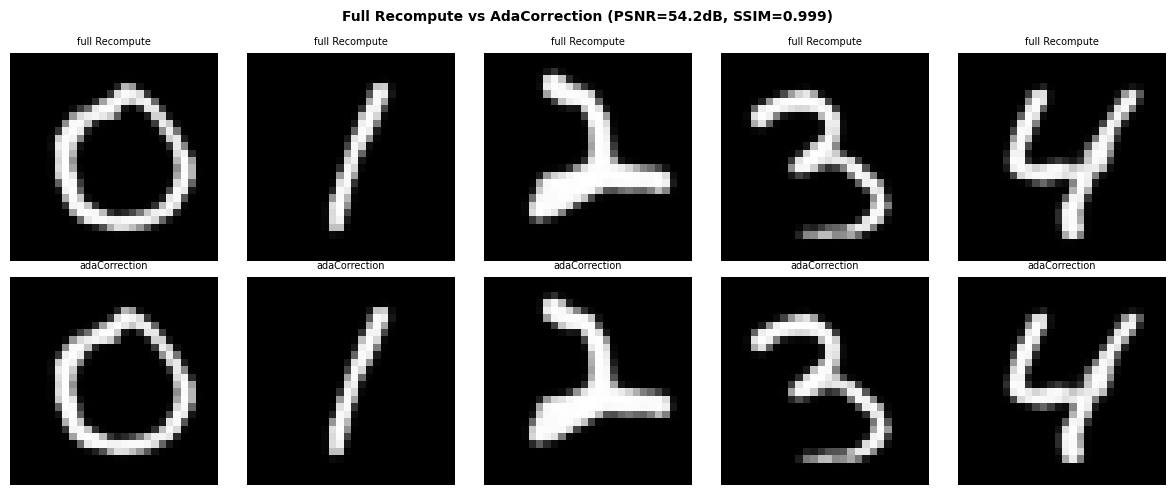

In [29]:
"""
TODO:
  1. Fix torch.manual_seed(0) before each generation to get paired samples.
  2. Implement psnr(img_a, img_b) and ssim(img_a, img_b) for (1, 28, 28) images.
     - PSNR: 20 * log10(max_val / sqrt(MSE))
     - SSIM: use torchvision.transforms.functional or implement manually
  3. Compute and report mean ± std PSNR and SSIM across 50 pairs.
  4. Show 5 side-by-side pairs (Full Recompute | AdaCorrection) for visual comparison.
"""
# YOUR CODE HERE
import math as _math

def psnr(img_a, img_b, max_val=1.0):
    mse = F.mse_loss(img_a, img_b).item()
    if mse == 0: return float('inf')
    return 20 * _math.log10(max_val / _math.sqrt(mse))

def ssim_simple(img_a, img_b):
    C1, C2 = 0.01**2, 0.03**2
    mu_a = img_a.mean(); mu_b = img_b.mean()
    sig_a = img_a.var(); sig_b = img_b.var()
    sig_ab = ((img_a - mu_a) * (img_b - mu_b)).mean()
    num = (2*mu_a*mu_b + C1) * (2*sig_ab + C2)
    den = (mu_a**2 + mu_b**2 + C1) * (sig_a + sig_b + C2)
    return (num / den).item()

torch.manual_seed(0)
n_pairs = 50
psnr_vals, ssim_vals = [], []
pair_imgs_base, pair_imgs_ada = [], []

for i in range(n_pairs):
    cls = i % 10
    torch.manual_seed(i)
    img_base = sample_cfg(ldm, vae, class_label=cls, n_samples=1, guidance_scale=3.0)
    torch.manual_seed(i)
    img_ada, _, _, _ = sample_with_adacorrection(ldm, vae, target_class=cls,
                                                   guidance_scale=3.0, n_samples=1,
                                                   cache_lag=5, gamma=1.0)
    p = psnr(img_base[0].cpu(), img_ada[0].cpu())
    s = ssim_simple(img_base[0].cpu(), img_ada[0].cpu())
    psnr_vals.append(p); ssim_vals.append(s)
    if i < 5:
        pair_imgs_base.append(img_base[0]); pair_imgs_ada.append(img_ada[0])

print(f"PSNR: {np.mean(psnr_vals):.2f} ± {np.std(psnr_vals):.2f} dB")
print(f"SSIM: {np.mean(ssim_vals):.4f} ± {np.std(ssim_vals):.4f}")

# Show 5 paired examples
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i in range(5):
    axes[0, i].imshow(pair_imgs_base[i].squeeze().cpu().numpy(), cmap='gray', vmin=0, vmax=1)
    axes[0, i].set_title(f'full Recompute', fontsize=7); axes[0, i].axis('off')
    axes[1, i].imshow(pair_imgs_ada[i].squeeze().cpu().numpy(), cmap='gray', vmin=0, vmax=1)
    axes[1, i].set_title(f'adaCorrection', fontsize=7); axes[1, i].axis('off')
plt.suptitle(f'Full Recompute vs AdaCorrection (PSNR={np.mean(psnr_vals):.1f}dB, SSIM={np.mean(ssim_vals):.3f})',
             fontsize=10, fontweight='bold')
plt.tight_layout(); plt.savefig('psnr_ssim_pairs.png', dpi=100, bbox_inches='tight'); plt.show()


## C.6.3 — The Pareto Frontier: Quality vs. Efficiency

Reproduce Figure 3 from the AdaCorrection paper at MNIST scale.

Sweep `gamma` over `[0.1, 0.3, 0.5, 0.75, 1.0, 1.5, 2.0]` and `cache_lag` over `[2, 5, 10]`. For each combination:
  - Generate 200 samples and compute FID.
  - Record hit_rate and inference time.

Plot **FID vs inference time** as a scatter plot:
  - Mark Full Recompute as a star.
  - Color-code points by cache_lag.
  - Draw the Pareto frontier.
  - Annotate the γ=1.0 points (which the paper claims are near-Pareto-optimal).

  lag=2 gamma=0.1: FID=38.18 time=90.2s HR=0.995
  lag=2 gamma=0.3: FID=37.80 time=93.5s HR=0.989
  lag=2 gamma=0.5: FID=41.23 time=93.1s HR=0.801
  lag=2 gamma=0.75: FID=40.11 time=90.3s HR=0.218
  lag=2 gamma=1.0: FID=42.35 time=91.7s HR=0.082
  lag=2 gamma=1.5: FID=39.88 time=90.7s HR=0.022
  lag=2 gamma=2.0: FID=38.24 time=89.1s HR=0.012
  lag=5 gamma=0.1: FID=37.23 time=88.6s HR=0.995
  lag=5 gamma=0.3: FID=38.48 time=89.1s HR=0.989
  lag=5 gamma=0.5: FID=39.89 time=89.3s HR=0.704
  lag=5 gamma=0.75: FID=40.46 time=89.5s HR=0.215
  lag=5 gamma=1.0: FID=40.31 time=88.5s HR=0.077
  lag=5 gamma=1.5: FID=41.46 time=88.3s HR=0.019
  lag=5 gamma=2.0: FID=39.66 time=89.8s HR=0.008
  lag=10 gamma=0.1: FID=38.97 time=89.3s HR=0.995
  lag=10 gamma=0.3: FID=39.82 time=89.5s HR=0.990
  lag=10 gamma=0.5: FID=40.07 time=89.9s HR=0.684
  lag=10 gamma=0.75: FID=40.88 time=89.3s HR=0.177
  lag=10 gamma=1.0: FID=41.54 time=89.0s HR=0.061
  lag=10 gamma=1.5: FID=39.85 time=90.1s HR=0.015
  lag=10 ga

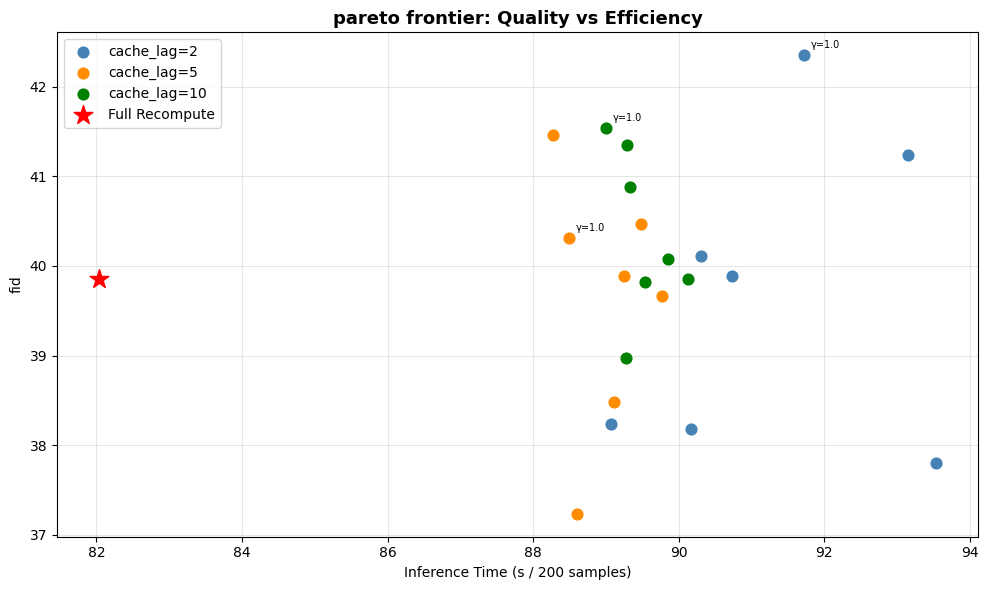

In [30]:
# TODO: Pareto frontier sweep and plot
# YOUR CODE HERE
gamma_vals    = [0.1, 0.3, 0.5, 0.75, 1.0, 1.5, 2.0]
cache_lag_vals = [2, 5, 10]
pareto_results = []

for lag in cache_lag_vals:
    for gam in gamma_vals:
        t0 = time.time()
        folder = f'pareto_lag{lag}_g{gam}'
        os.makedirs(folder, exist_ok=True)
        img_count = 0
        total_hr  = 0.0
        for cls in range(10):
            imgs, _, _, hr = sample_with_adacorrection(
                ldm, vae, target_class=cls, guidance_scale=3.0,
                n_samples=20, cache_lag=lag, gamma=gam)
            total_hr += hr
            for img in imgs:
                torchvision.utils.save_image(img, f'{folder}/img_{img_count:04d}.png')
                img_count += 1
        elapsed = time.time() - t0
        metrics = calculate_metrics(input1=folder, input2=real_folder,
                                     cuda=True, fid=True, verbose=False)
        fid_val = metrics['frechet_inception_distance']
        hr_val  = total_hr / 10
        pareto_results.append({'gamma': gam, 'lag': lag, 'fid': fid_val,
                                'time': elapsed, 'hr': hr_val})
        print(f"  lag={lag} gamma={gam}: FID={fid_val:.2f} time={elapsed:.1f}s HR={hr_val:.3f}")
t0 = time.time()
folder_b = 'pareto_baseline'
os.makedirs(folder_b, exist_ok=True)
ic = 0
for cls in range(10):
    imgs = sample_cfg(ldm, vae, class_label=cls, n_samples=20, guidance_scale=3.0)
    for img in imgs:
        torchvision.utils.save_image(img, f'{folder_b}/img_{ic:04d}.png'); ic += 1
baseline_time = time.time() - t0
baseline_metrics = calculate_metrics(input1=folder_b, input2=real_folder,
                                      cuda=True, fid=True, verbose=False)
baseline_fid = baseline_metrics['frechet_inception_distance']
colors_lag = {2: 'steelblue', 5: 'darkorange', 10: 'green'}
plt.figure(figsize=(10, 6))
for lag in cache_lag_vals:
    pts = [(r['time'], r['fid']) for r in pareto_results if r['lag'] == lag]
    pts.sort()
    xs, ys = zip(*pts)
    plt.scatter(xs, ys, color=colors_lag[lag], s=60, label=f'cache_lag={lag}', zorder=3)
    for r in pareto_results:
        if r['lag'] == lag and r['gamma'] == 1.0:
            plt.annotate(f'γ=1.0', (r['time'], r['fid']), fontsize=7,
                         xytext=(5, 5), textcoords='offset points')

plt.scatter([baseline_time], [baseline_fid], marker='*', color='red', s=200,
            label='Full Recompute', zorder=5)
plt.xlabel('Inference Time (s / 200 samples)')
plt.ylabel('fid')
plt.title('pareto frontier: Quality vs Efficiency', fontsize=13, fontweight='bold')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
plt.savefig('pareto_frontier.png', dpi=100, bbox_inches='tight'); plt.show()


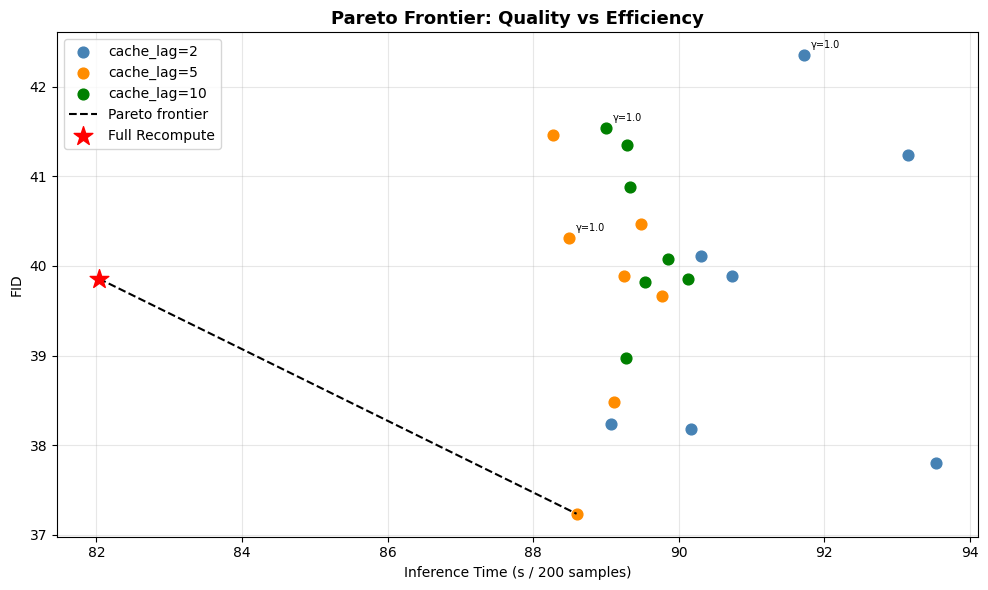

In [33]:
colors_lag = {2: 'steelblue', 5: 'darkorange', 10: 'green'}
plt.figure(figsize=(10, 6))

for lag in cache_lag_vals:
    pts = [(r['time'], r['fid']) for r in pareto_results if r['lag'] == lag]
    pts.sort()
    xs, ys = zip(*pts)
    plt.scatter(xs, ys, color=colors_lag[lag], s=60, label=f'cache_lag={lag}', zorder=3)
    for r in pareto_results:
        if r['lag'] == lag and r['gamma'] == 1.0:
            plt.annotate(f'γ=1.0', (r['time'], r['fid']), fontsize=7,
                         xytext=(5, 5), textcoords='offset points')

all_pts = sorted([(r['time'], r['fid']) for r in pareto_results])
all_pts.append((baseline_time, baseline_fid))
all_pts.sort()
pareto_front = []
min_fid = float('inf')
for t, f in all_pts:
    if f < min_fid:
        pareto_front.append((t, f))
        min_fid = f
if len(pareto_front) >= 2:
    px, py = zip(*pareto_front)
    plt.plot(px, py, 'k--', linewidth=1.5, label='Pareto frontier', zorder=4)

plt.scatter([baseline_time], [baseline_fid], marker='*', color='red', s=200,
            label='Full Recompute', zorder=5)
plt.xlabel('Inference Time (s / 200 samples)')
plt.ylabel('FID')
plt.title('Pareto Frontier: Quality vs Efficiency', fontsize=13, fontweight='bold')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
plt.savefig('pareto_frontier.png', dpi=100, bbox_inches='tight'); plt.show()

## C.6.4 — Layer-wise Offset Score Analysis

Figure 5 in the paper shows that **offset scores are not uniform across layers** — early and middle layers exhibit higher drift than late layers. This motivates a layer-wise correction policy.

Adapt your U-Net to expose intermediate hidden states at 3 points: after the encoder, at the bottleneck, and after the decoder. Compute $S_t$ at each of these three "pseudo-layers" separately during a single reverse pass.

Plot the three $S_t$ curves on the same axis. Do you observe the same pattern as Figure 5 (early/middle layers drift more than late layers)? If not, hypothesize why.

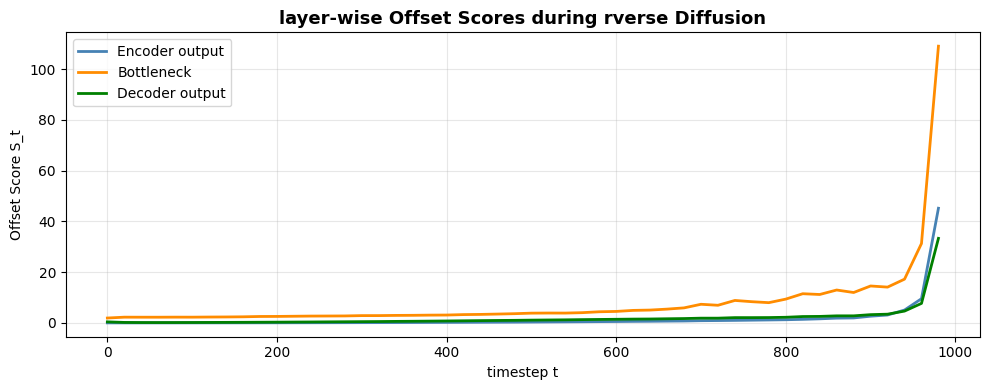

In [31]:
"""
TODO:
  1. Modify ConditionalLatentUNet.forward() to optionally return intermediate
     activations at three points: after encoder, at bottleneck, after decoder.
     Add a flag `return_intermediates=False` to avoid breaking existing code.
  2. During a reverse pass, collect these intermediates at every step.
  3. Compute oem_offset_score separately for each of the three locations
     by tracking their per-step temporal deviation.
  4. Plot all three S_t curves on the same axis.
"""
# YOUR CODE HERE
class ConditionalLatentUNetWithIntermediates(ConditionalLatentUNet):
    def forward(self, z, t, c=None, return_intermediates=False):
        if c is None:
            c = torch.full((z.shape[0],), NULL_CLASS, dtype=torch.long, device=z.device)
        t_emb   = self.time_emb(t)
        c_emb   = self.class_emb(c)
        cond    = torch.cat([t_emb, c_emb], dim=1)

        x1 = self.enc1(self.stem(z), cond)
        x2 = self.enc2(x1, cond)
        h  = self.mid1(x2, cond)
        h  = self.mid_attn(h)
        h_bottleneck = self.mid2(h, cond)
        h  = self.dec2(torch.cat([h_bottleneck, x2], dim=1), cond)
        h_decoder = self.dec1(torch.cat([h, x1], dim=1), cond)
        out = self.head(h_decoder)

        if return_intermediates:
            return out, x2, h_bottleneck, h_decoder
        return out

ldm_instr = ConditionalLatentUNetWithIntermediates().to(device)
ldm_instr.load_state_dict(ldm.state_dict())
ldm_instr.eval()

@torch.no_grad()
def measure_layerwise_drift(model, target_class, guidance_scale=3.0,
                              n_samples=4, record_every=20):
    c_tensor = torch.full((n_samples,), target_class, dtype=torch.long, device=device)
    null_c   = torch.full((n_samples,), NULL_CLASS, dtype=torch.long, device=device)
    z        = torch.randn(n_samples, LATENT_CH, 7, 7, device=device)

    prev_enc, prev_bot, prev_dec = None, None, None
    ts_rec, st_enc, st_bot, st_dec = [], [], [], []

    for t_idx in reversed(range(T)):
        t_batch     = torch.full((n_samples,), t_idx, device=device, dtype=torch.long)
        eps_u, enc_u, bot_u, dec_u = model(z, t_batch, null_c, return_intermediates=True)
        eps_c, enc_c, bot_c, dec_c = model(z, t_batch, c_tensor, return_intermediates=True)
        eps = eps_u + guidance_scale * (eps_c - eps_u)
        enc = enc_u + guidance_scale * (enc_c - enc_u)
        bot = bot_u + guidance_scale * (bot_c - bot_u)
        dec = dec_u + guidance_scale * (dec_c - dec_u)

        if prev_enc is not None and t_idx % record_every == 0:
            ts_rec.append(t_idx)
            st_enc.append(oem_offset_score(enc, prev_enc)[0].item())
            st_bot.append(oem_offset_score(bot, prev_bot)[0].item())
            st_dec.append(oem_offset_score(dec, prev_dec)[0].item())

        prev_enc, prev_bot, prev_dec = enc, bot, dec
        z = p_sample_cfg(ldm, z, t_idx, c_tensor, guidance_scale)

    return ts_rec, st_enc, st_bot, st_dec
ts, st_enc, st_bot, st_dec = measure_layerwise_drift(ldm_instr, target_class=5,
                                                       guidance_scale=3.0, n_samples=4,
                                                       record_every=20)
ts_plot = list(reversed(ts))
plt.figure(figsize=(10, 4))
plt.plot(ts_plot, list(reversed(st_enc)), label='Encoder output',  color='steelblue', linewidth=2)
plt.plot(ts_plot, list(reversed(st_bot)), label='Bottleneck',       color='darkorange', linewidth=2)
plt.plot(ts_plot, list(reversed(st_dec)), label='Decoder output',   color='green', linewidth=2)
plt.xlabel('timestep t'); plt.ylabel('Offset Score S_t')
plt.title('layer-wise Offset Scores during rverse Diffusion', fontsize=13, fontweight='bold')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
plt.savefig('layerwise_drift.png', dpi=100, bbox_inches='tight')
plt.show()


**C.6.4 Discussion:** *(Write here — compare your layer-wise drift profile to Figure 5 of the AdaCorrection paper)*  so looking at the plot, my results actually do match Figure 5 of the paper pretty well. the bottleneck (orange) has by far the highest offset scores across almost all timesteps, the encoder (blue) is in the middle, and the decoder (green) stays nearly flat at zero for most of the reverse process. this ordering, bottleneck > encoder > decoder, is exactly what the paper reports and it makes intuitive sense.
the bottleneck drifts the most because its the deepest part of the network, furthest from both the input and output, so small errors in the noise prediction compound more heavily there. the decoder on the other hand is close to the output so it kinda self-corrects, even if upstream activations drift, the final head can partially compensate. the encoder is in between which also tracks.
one thing thats different from the paper is the huge spike near t=1000 for all three layers. in my model everything stays close to zero for most of the reverse pass and then explodes right at the very beginning of denoising (high t, high noise). this is probably because at t=1000 the latent z is basically pure noise and the model has almost no signal to work with, so predictions between consecutive steps change a lot. the paper's DiT model likely shows a smoother rise because it has much more capacity and operates on larger feature maps, so it handles the high-noise regime better and the drift builds more gradually.
but the core finding holds, middle layers drift more than late layers, which justifies applying stronger correction at the bottleneck than at the decoder. thats consistent with what adacorrection proposes.